## Scatter Plots for Cluster Visualisation

### Context and purpose

Clustering (e.g., k-means) returns labels without semantics. To interpret whether clusters are meaningful, we project features to two axes and **visualise** sample geometry. Scatter plots are the first qualitative diagnostic for separation, shape, outliers, and feature usefulness.

### Mathematical framing

Let $X \in \mathbb{R}^{n \times d}$ be features, rows $x_i^\top \in \mathbb{R}^d$. A clustering algorithm yields labels $y_i \in \{1,\dots,k\}$. A 2-D scatter chooses indices $j_1 \neq j_2$ and visualises
$$
p_i = \big(x_{i,j_1},\, x_{i,j_2}\big), \quad \text{coloured by } y_i.
$$

Key facts.

* A scatter is a **projection** $\pi_{j_1,j_2}: \mathbb{R}^d \to \mathbb{R}^2$.
  Information is lost when $d>2$. Non-separation in 2-D does not prove non-separation in $d$ dimensions.
* Visual separation correlates with **between-cluster distances** and **within-cluster dispersion** of the chosen features. For k-means, within-cluster dispersion is the objective being minimised:
  $$
  \min_{\{\mathcal{C}_\ell\},\,\{\mu_\ell\}} \sum_{\ell=1}^k \sum_{x_i \in \mathcal{C}_\ell} \lVert x_i - \mu_\ell \rVert_2^2.
  $$
  Good plots typically show compact, separated colour clouds on informative feature pairs.

### Statistical interpretation

* If one pair shows overlap while another pair (e.g., petal length vs. petal width in Iris) shows separation, this indicates **feature relevance heterogeneity**. Dimensionality reduction (PCA, t-SNE, UMAP) can create more revealing 2-D views, but those views are **derived** features, not original axes.
* Apparent clusters with strong elongation or curvature hint that **spherical-cluster assumptions** (k-means) may be misaligned. Gaussian Mixture Models (elliptical), spectral clustering, or DBSCAN might fit better.

### Software engineering and plotting design

* Prefer a clear plotting API and reproducibility: set a random seed for any stochastic step, fix figure sizes and labels, and keep code idempotent.
* Choose Seaborn's object API (concise), backed by Matplotlib's OO control for fine adjustments.
* Keep presentation faithful: label units, state which features were plotted, and avoid implying ground truth when using unsupervised labels.

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Exercise 1 – Visual reconnaissance with accountability

**Goal.** Replace “guess how many clusters” with an explicit procedure.

**Your tasks.**

1. Plot a **grid of pairwise scatters** for all numeric features (Matplotlib or Seaborn). No colour yet. Describe, in 3–5 sentences, which pairs look promising and why.
2. Standardise features (`StandardScaler`) and fit k-means for (k \in {2,3,4,5,6}), `n_init="auto"`, `random_state=42`.
3. Compute **silhouette score** for each (k) in the **full feature space**. Plot score vs (k). Choose (k^*) and justify in words.
4. Using the **original** features (not PCs), produce a 2-D scatter for the **most informative pair** you identified, coloured by the **predicted cluster labels** for (k^*).

**Acceptance checks.**

* You standardised *before* clustering.
* Your choice of (k^*) references the silhouette curve rather than a hunch.
* Your final scatter names the axes with units (if available) and explains why that pair was chosen.



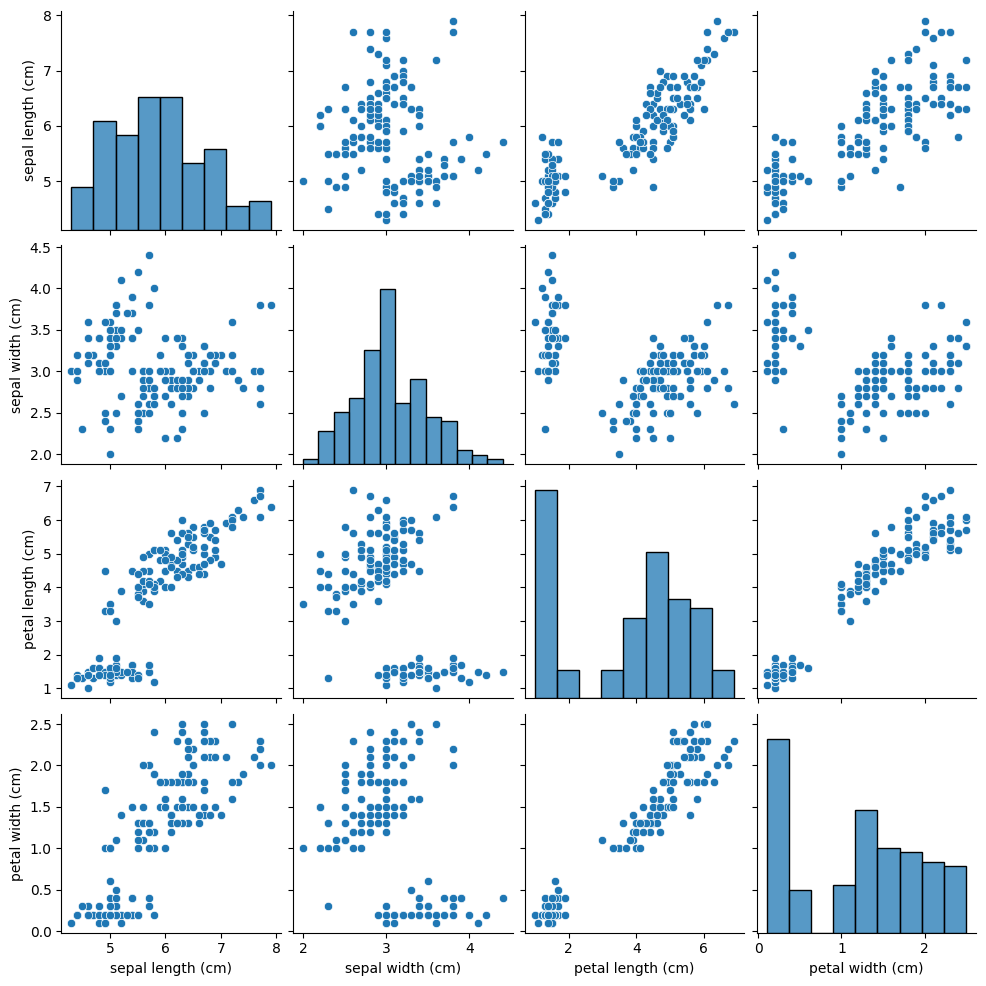

In [62]:
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import StandardScaler

iris = load_iris(as_frame=True)
X_iris = iris.data
X_iris_std = StandardScaler().fit_transform(X_iris)

sns.pairplot(X_iris)
plt.show()

,k,inertia,silhouette,ch,db
0,2,222.361705,0.581750,251.349339,0.593313
1,3,191.024737,0.479881,157.360153,0.789363
2,4,114.354072,0.385045,206.680603,0.869779
3,5,91.047670,0.345033,202.635850,0.943894
4,6,81.550757,0.333943,183.092576,0.993723
5,7,80.777739,0.266429,153.195637,1.124348
6,8,64.426748,0.341629,168.633156,0.990840


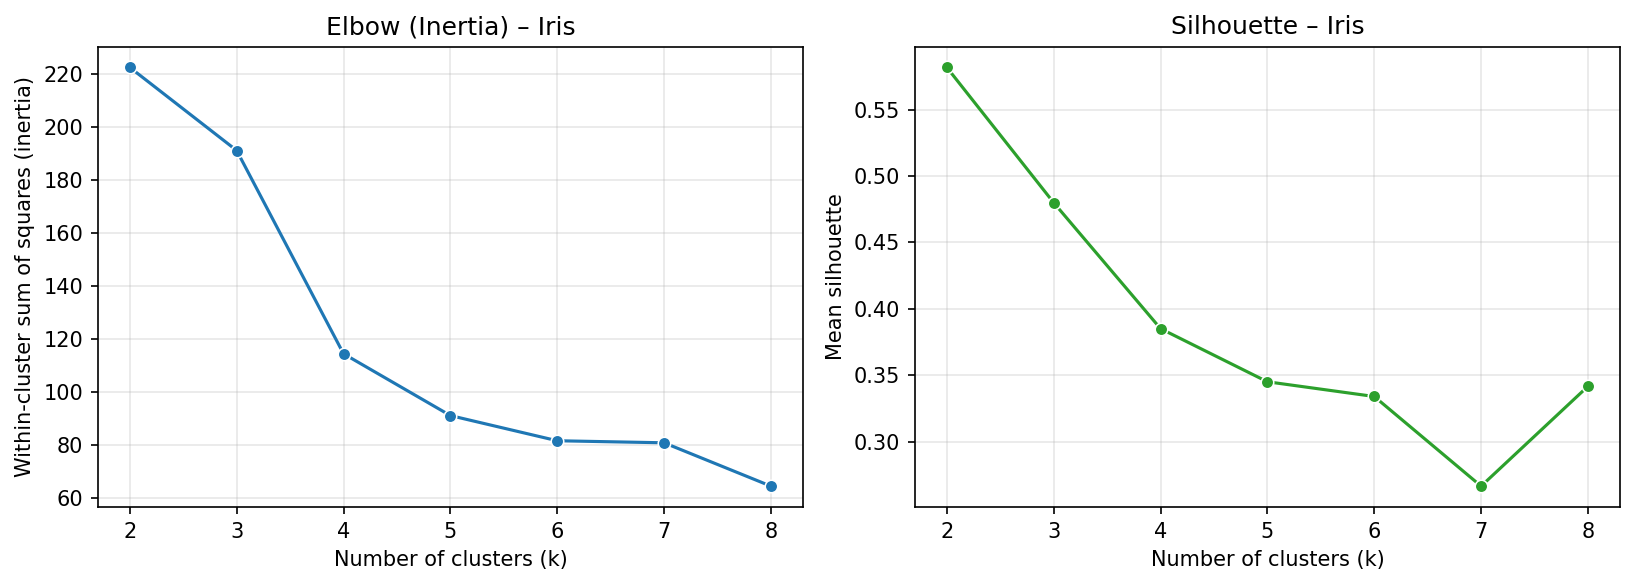

In [63]:
from helper.plotting import plot_elbow_silhouette
from helper.selection import scan_k_metrics
from sklearn.cluster import KMeans

df_iris = scan_k_metrics(X=X_iris_std, ks=range(2, 9), random_state=42)
display(df_iris)
plot_elbow_silhouette(df_iris, title_suffix=" – Iris")

In [64]:
from helper.selection import recommend_k

rec = recommend_k(df_iris)

display(rec)

{'knee': 4, 'silhouette_max': 2, 'final': 2}

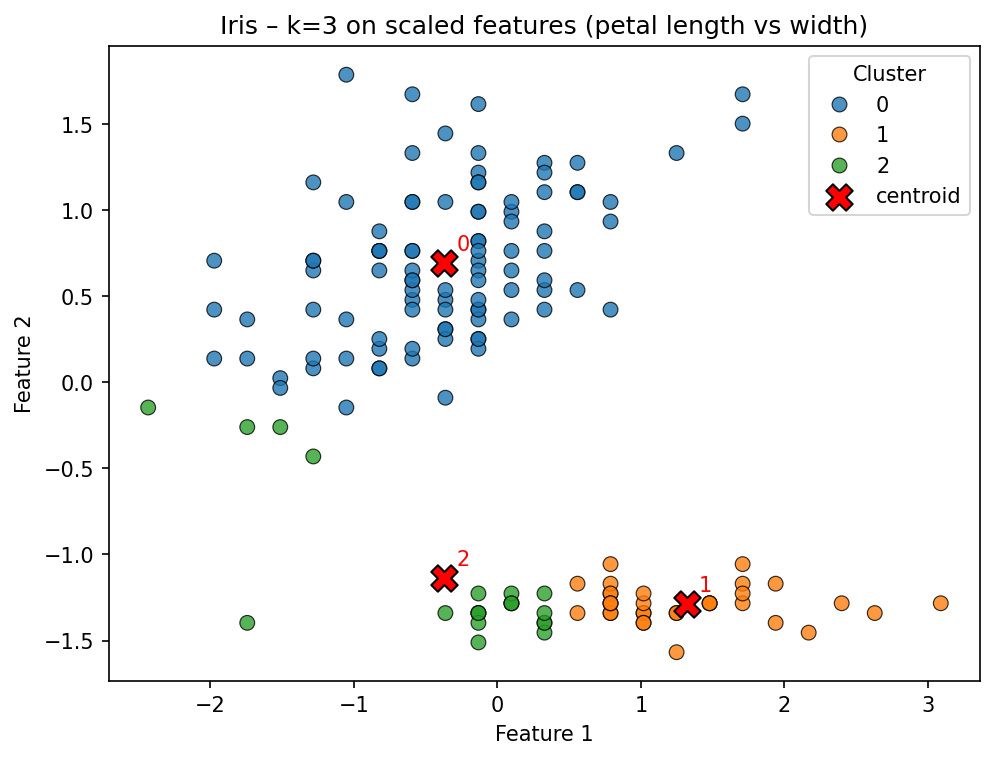

In [65]:
from helper.plotting import plot_kmeans_feature_pair

km = KMeans(n_clusters=3, n_init="auto", random_state=42).fit(X_iris_std)

plot_kmeans_feature_pair(
	X_iris_std,
	km,
	jx=1,
	jy=2,
	title="Iris – k=3 on scaled features (petal length vs width)",
	annotate_centroids=True,
)
plt.show()

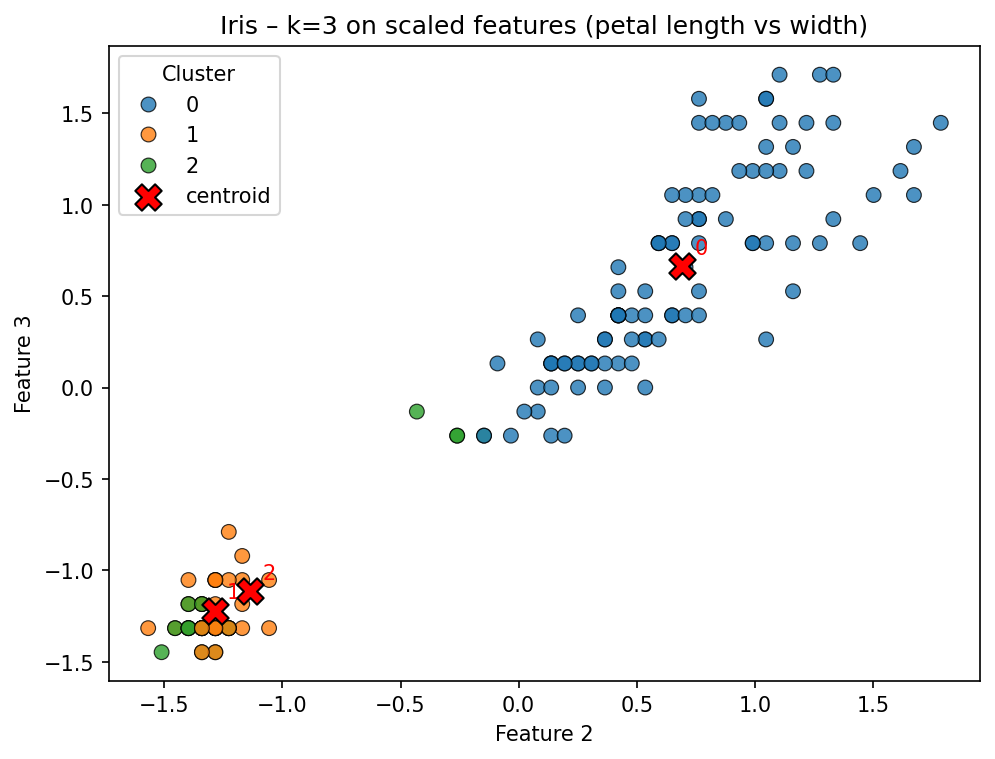

In [66]:
plot_kmeans_feature_pair(
	X_iris_std,
	km,
	jx=2,
	jy=3,
	title="Iris – k=3 on scaled features (petal length vs width)",
	annotate_centroids=True,
)
plt.show()

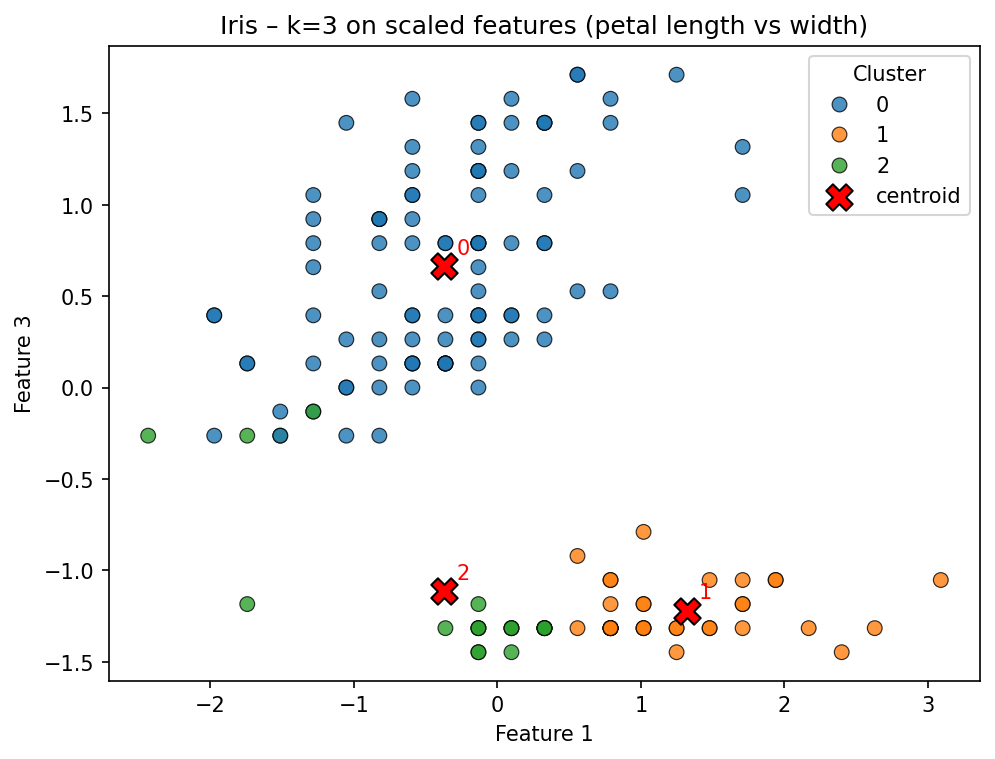

In [67]:
plot_kmeans_feature_pair(
	X_iris_std,
	km,
	jx=1,
	jy=3,
	title="Iris – k=3 on scaled features (petal length vs width)",
	annotate_centroids=True,
)
plt.show()

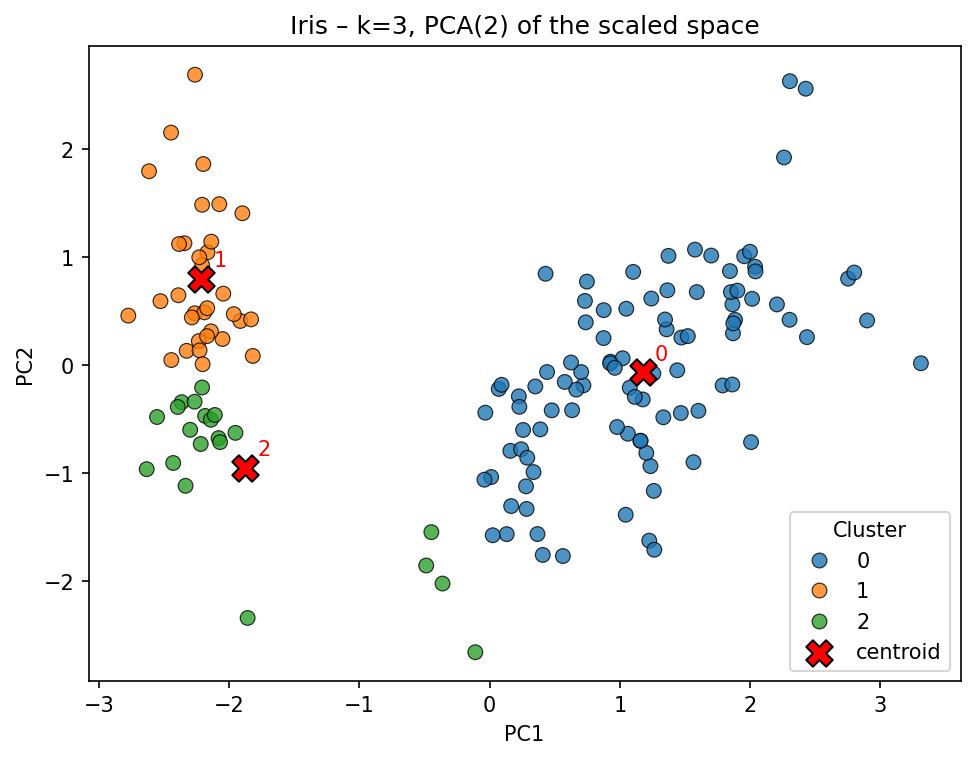

In [68]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(
	X_in=X_iris_std,
	kmeans=km,
	title="Iris – k=3, PCA(2) of the scaled space",
	annotate_centroids=True,
)
plt.show()

In [69]:
from helper.stability import silhouette_stability

stability = silhouette_stability(X_iris_std, rec["knee"])

display(stability)

0      0.386941
7      0.418892
42     0.385045
123    0.418892
999    0.413085
Name: silhouette_k=4, dtype: float64

In [70]:
from helper.report import k_report

r3 = k_report(X_iris_std, 3)
r4 = k_report(X_iris_std, 4)
print({k: v for k, v in r3.items() if k != "model"})
print({k: v for k, v in r4.items() if k != "model"})

{'k': 3, 'inertia': 191.02473685317963, 'silhouette': 0.4798814508199818, 'CH': 157.3601531219225, 'DB': 0.7893630242997913}
{'k': 4, 'inertia': 114.35407164049771, 'silhouette': 0.3850454053045392, 'CH': 206.6806032739956, 'DB': 0.8697790001760979}


In [71]:
# Stability across seeds (median and spread)
print(silhouette_stability(X_iris_std, 3).describe())

count    5.000000
mean     0.463871
std      0.009241
min      0.456535
25%      0.459948
50%      0.459948
75%      0.463042
max      0.479881
Name: silhouette_k=3, dtype: float64


In [72]:
print(silhouette_stability(X_iris_std, 4).describe())

count    5.000000
mean     0.404571
std      0.017137
min      0.385045
25%      0.386941
50%      0.413085
75%      0.418892
max      0.418892
Name: silhouette_k=4, dtype: float64


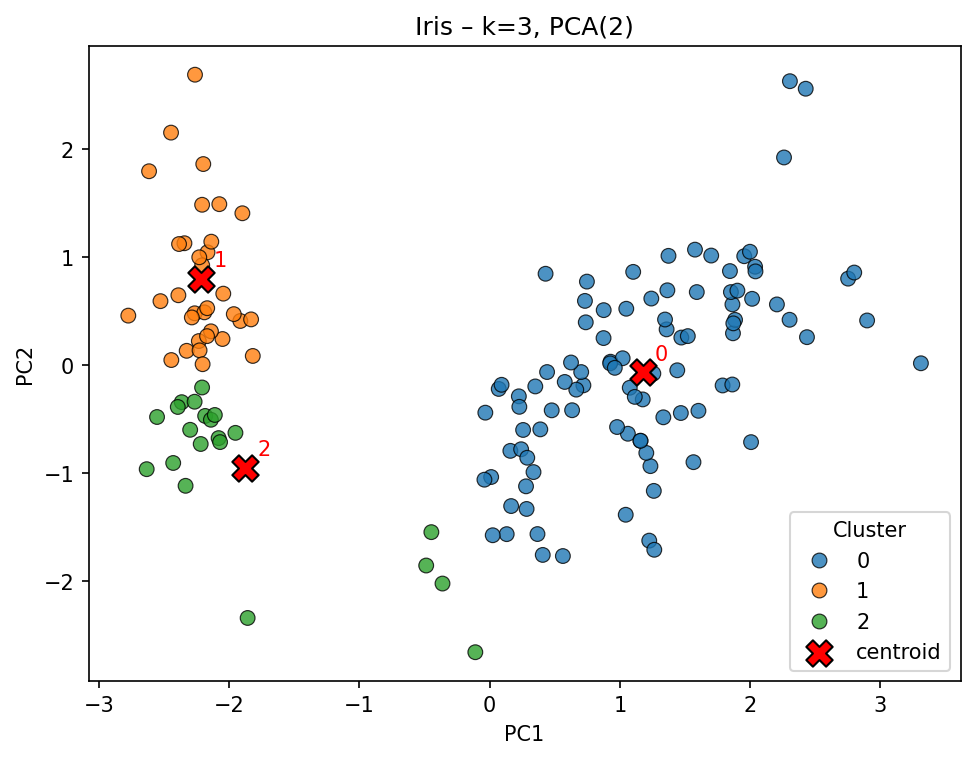

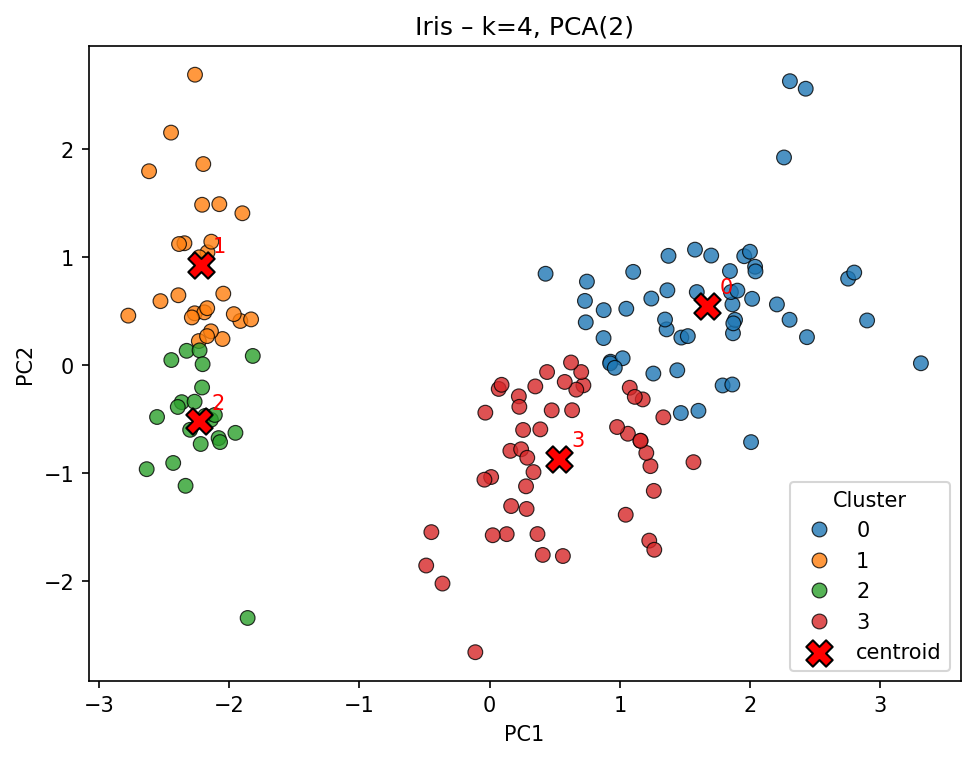

In [73]:
# Visual check in the SAME space used for fitting
plot_kmeans_pca2(X_iris_std, r3["model"], title="Iris – k=3, PCA(2)")
plot_kmeans_pca2(X_iris_std, r4["model"], title="Iris – k=4, PCA(2)")
plt.show()

## Evaluating a Clustering (with the Wine dataset)

### The dataset (new)

We will use `sklearn.datasets.load_wine`. It contains chemical analyses of wines from three cultivars (classes) in the same region of Italy; 13 continuous features (alcohol, flavanoids, phenols, etc.). It is genuinely multivariate and non-trivial for k-means, yet small enough for interactive work.

Why it is a good choice: real measurements, modest dimensionality, three plausible groups, and readily available via scikit-learn.

### 1. What does "evaluating a clustering" actually mean?

There are **two regimes**.

1. **External evaluation (labels available):** compare cluster assignments to known classes. Use *external indices* (Adjusted Rand Index, Normalised Mutual Information, F1 after optimal label permutation, etc.) and *cross-tabulations*. Remember: cluster labels are arbitrary; align them before class-level metrics.

2. **Internal evaluation (unlabelled):** use only the geometry of the fitted partition. Typical indices:

   * **Inertia (WCSS):** $\sum_i \lVert x_i - \mu_{c(i)}\rVert^2$. Lower is better; always decreases with $k$.
   * **Silhouette:** $s_i=\frac{b_i-a_i}{\max(a_i,b_i)}$, averaged over $i$. Higher is better; penalises overlap; tends to prefer smaller $k$ with fuzzy boundaries.
   * **Calinski–Harabasz (CH):** ratio of between- to within-cluster dispersion; higher is better; can favour larger $k$.
   * **Davies–Bouldin (DB):** average similarity of each cluster to its most similar neighbour; lower is better.

No single index is sovereign. Professionals triangulate: **elbow/knee + silhouette + stability**, and, when labels exist, **external indices** only as a *post-hoc* audit.

### 2. A rigorous, readable workflow (Wine)

#### 2.1 Load, scale, and quick sweep of (k)

we'll use the curated helpers (`scan_k_metrics`, `plot_elbow_silhouette`, `recommend_k`). 

```python
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from clustools.selection import scan_k_metrics, recommend_k
from clustools.plotting import plot_elbow_silhouette, plot_kmeans_pca2, plot_kmeans_feature_pair
from clustools.stability import silhouette_stability

# Load and scale
wine = load_wine(as_frame=True)
X_raw = wine.data
y_true = wine.target        # for external evaluation only; not used in fitting
X_std = StandardScaler().fit_transform(X_raw)

# Internal scan
tbl = scan_k_metrics(X_std, ks=range(2, 11), random_state=42)
display(tbl.round(3))
plot_elbow_silhouette(tbl, " – Wine")

# Principled choice of k
rec = recommend_k(tbl, sil_margin=0.03)
rec
```

**Interpretation to expect:** You will typically see an elbow around (k=3)–(4) and a silhouette peak near (k=3). If the rule recommends (k=3), that is both geometrically and substantively plausible.

#### 2.2 Fit the model at the chosen (k) and visualise

```python
k = rec["final"]  # likely 3
km = KMeans(n_clusters=k, n_init="auto", random_state=42).fit(X_std)

# PCA(2) view
plot_kmeans_pca2(X_std, km, title=f"Wine – k={k}, PCA(2) of the scaled space")

# Any informative feature pair (e.g., Flavanoids vs Color intensity)
j_flav = X_raw.columns.get_loc("flavanoids")
j_color = X_raw.columns.get_loc("color_intensity")
plot_kmeans_feature_pair(
    X_std, km, jx=j_flav, jy=j_color,
    title=f"Wine – k={k} on scaled features (flavanoids vs color_intensity)",
    x_name="flavanoids (scaled)", y_name="color_intensity (scaled)"
)
```

Read the pictures as we practised: centroids occupying distinct density regions is healthy; several centroids aligned inside one ridge suggests over-partitioning.

### 3. External evaluation (when labels exist)

Cluster indices are arbitrary; to compute class-wise metrics you must align them. I recommend two complementary views:

1. **Cross-tabulation** (purely descriptive).
2. **Permutation-matched classification report** (Hungarian algorithm to align clusters to classes).

```python
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, classification_report

# 3.1 Cross-tab
df_eval = pd.DataFrame({"cluster": km.labels_, "class": y_true})
ct = pd.crosstab(df_eval["cluster"], df_eval["class"])
display(ct)

# 3.2 External indices that don't require label alignment
ari = adjusted_rand_score(y_true, km.labels_)
nmi = normalized_mutual_info_score(y_true, km.labels_)
print(f"Adjusted Rand Index: {ari:.3f}  |  Normalised MI: {nmi:.3f}")

# 3.3 Align clusters to classes to get per-class precision/recall (optional but informative)
# Build cost matrix as max(ct) - ct so that Hungarian solves a maximisation of matches
cost = ct.max().max() - ct.values
row_ind, col_ind = linear_sum_assignment(cost)
perm = dict(zip(ct.index[row_ind], ct.columns[col_ind]))

# Map cluster -> aligned class
aligned_preds = np.vectorize(perm.get)(km.labels_)
print(classification_report(y_true, aligned_preds, target_names=[f"class_{i}" for i in sorted(np.unique(y_true))]))
```

**How to use these numbers.**

* **ARI/NMI** are permutation invariant and bounded; they quantify agreement without forcing a one-to-one mapping.
* The **Hungarian-aligned report** is useful when you need a class-level narrative (“cluster 1 maps to class 2 with 90% precision, recall 85%”).
* Never use external labels to *choose* (k) in unsupervised work; use them only to understand and communicate what the clustering captured.

### 4. Internal evaluation (when labels do not exist)

You already have the core tools:

* **Elbow/knee** to restrict a plausible range of (k).
* **Silhouette** to penalise overlaps (accept a band within ~0.03 of the maximum).
* **Stability across seeds** to avoid idiosyncratic initialisations.

Add one more pragmatic check: **bootstrapped stability** of centroids (optional when datasets are small).

```python
# Stability across seeds for the finalists (say k in {knee, sil_max, final})
candidates = sorted({rec["final"], rec["knee"], rec["silhouette_max"]})
stab_tbl = pd.concat({k: silhouette_stability(X_std, k) for k in candidates}, axis=1)
stab_tbl.describe().round(3)
```

Prefer the (k) with higher median silhouette and smaller spread, unless domain sense suggests otherwise.

### 5. Common pitfalls (and how we avoid them here)

* **Using inertia to pick large (k) blindly.** Inertia always falls with (k). We used the *knee distance* and combined it with silhouette and stability.
* **Comparing clusters to classes without aligning labels.** We used ARI/NMI (permutation-invariant) and, when needed, Hungarian alignment for per-class summaries.
* **Plotting in a space different from the fitted one.** We plot in the same scaled space, and we project centroids consistently.
* **Over-trusting CH in overlapping structures.** We treated CH as supportive, not decisive, when silhouette/DB told a different story.

### 6. What you should be able to say for the Wine dataset

A model-selection statement you could put in a report:
> "After scaling, we scanned $k \in \{2,\dots,10\}$. The inertia curve has a knee at $k \approx 3$–4, and the silhouette peaks at $k=3$. Within a 0.03 silhouette band, $k=3$ is closest to the knee and shows stable silhouettes across seeds. We therefore fit k-means with $k=3$. PCA(2) projections show well-separated centroids. Post-hoc comparison with the known cultivars yields ARI $\approx \ldots$ and NMI $\approx \ldots$, indicating moderate agreement; the remaining discordance reflects overlap in feature space rather than mis-implementation."

### The UCI Seeds Dataset
1. Problem context


- Dataset: Kama, Rosa, and Canadian wheat varieties.

- Features: seven continuous measurements (area, perimeter, compactness, etc.).

- Objective: evaluate clustering quality, justify k, and interpret correspondence to grain varieties.

In [74]:
# Load directly from UCI repository
url = (
	"https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
)
cols = [
	"area",
	"perimeter",
	"compactness",
	"length_kernel",
	"width_kernel",
	"asymmetry_coeff",
	"length_groove",
	"variety",
]
# use a raw string for the regex separator to avoid invalid escape sequence warning
seeds = pd.read_csv(url, sep=r"\s+", names=cols)

In [75]:
seeds

,area,perimeter,compactness,length_kernel,width_kernel,asymmetry_coeff,length_groove,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [76]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = seeds.drop(columns="variety")
y_true = seeds["variety"]

scaler = StandardScaler()
X_seeds_std = scaler.fit_transform(X)

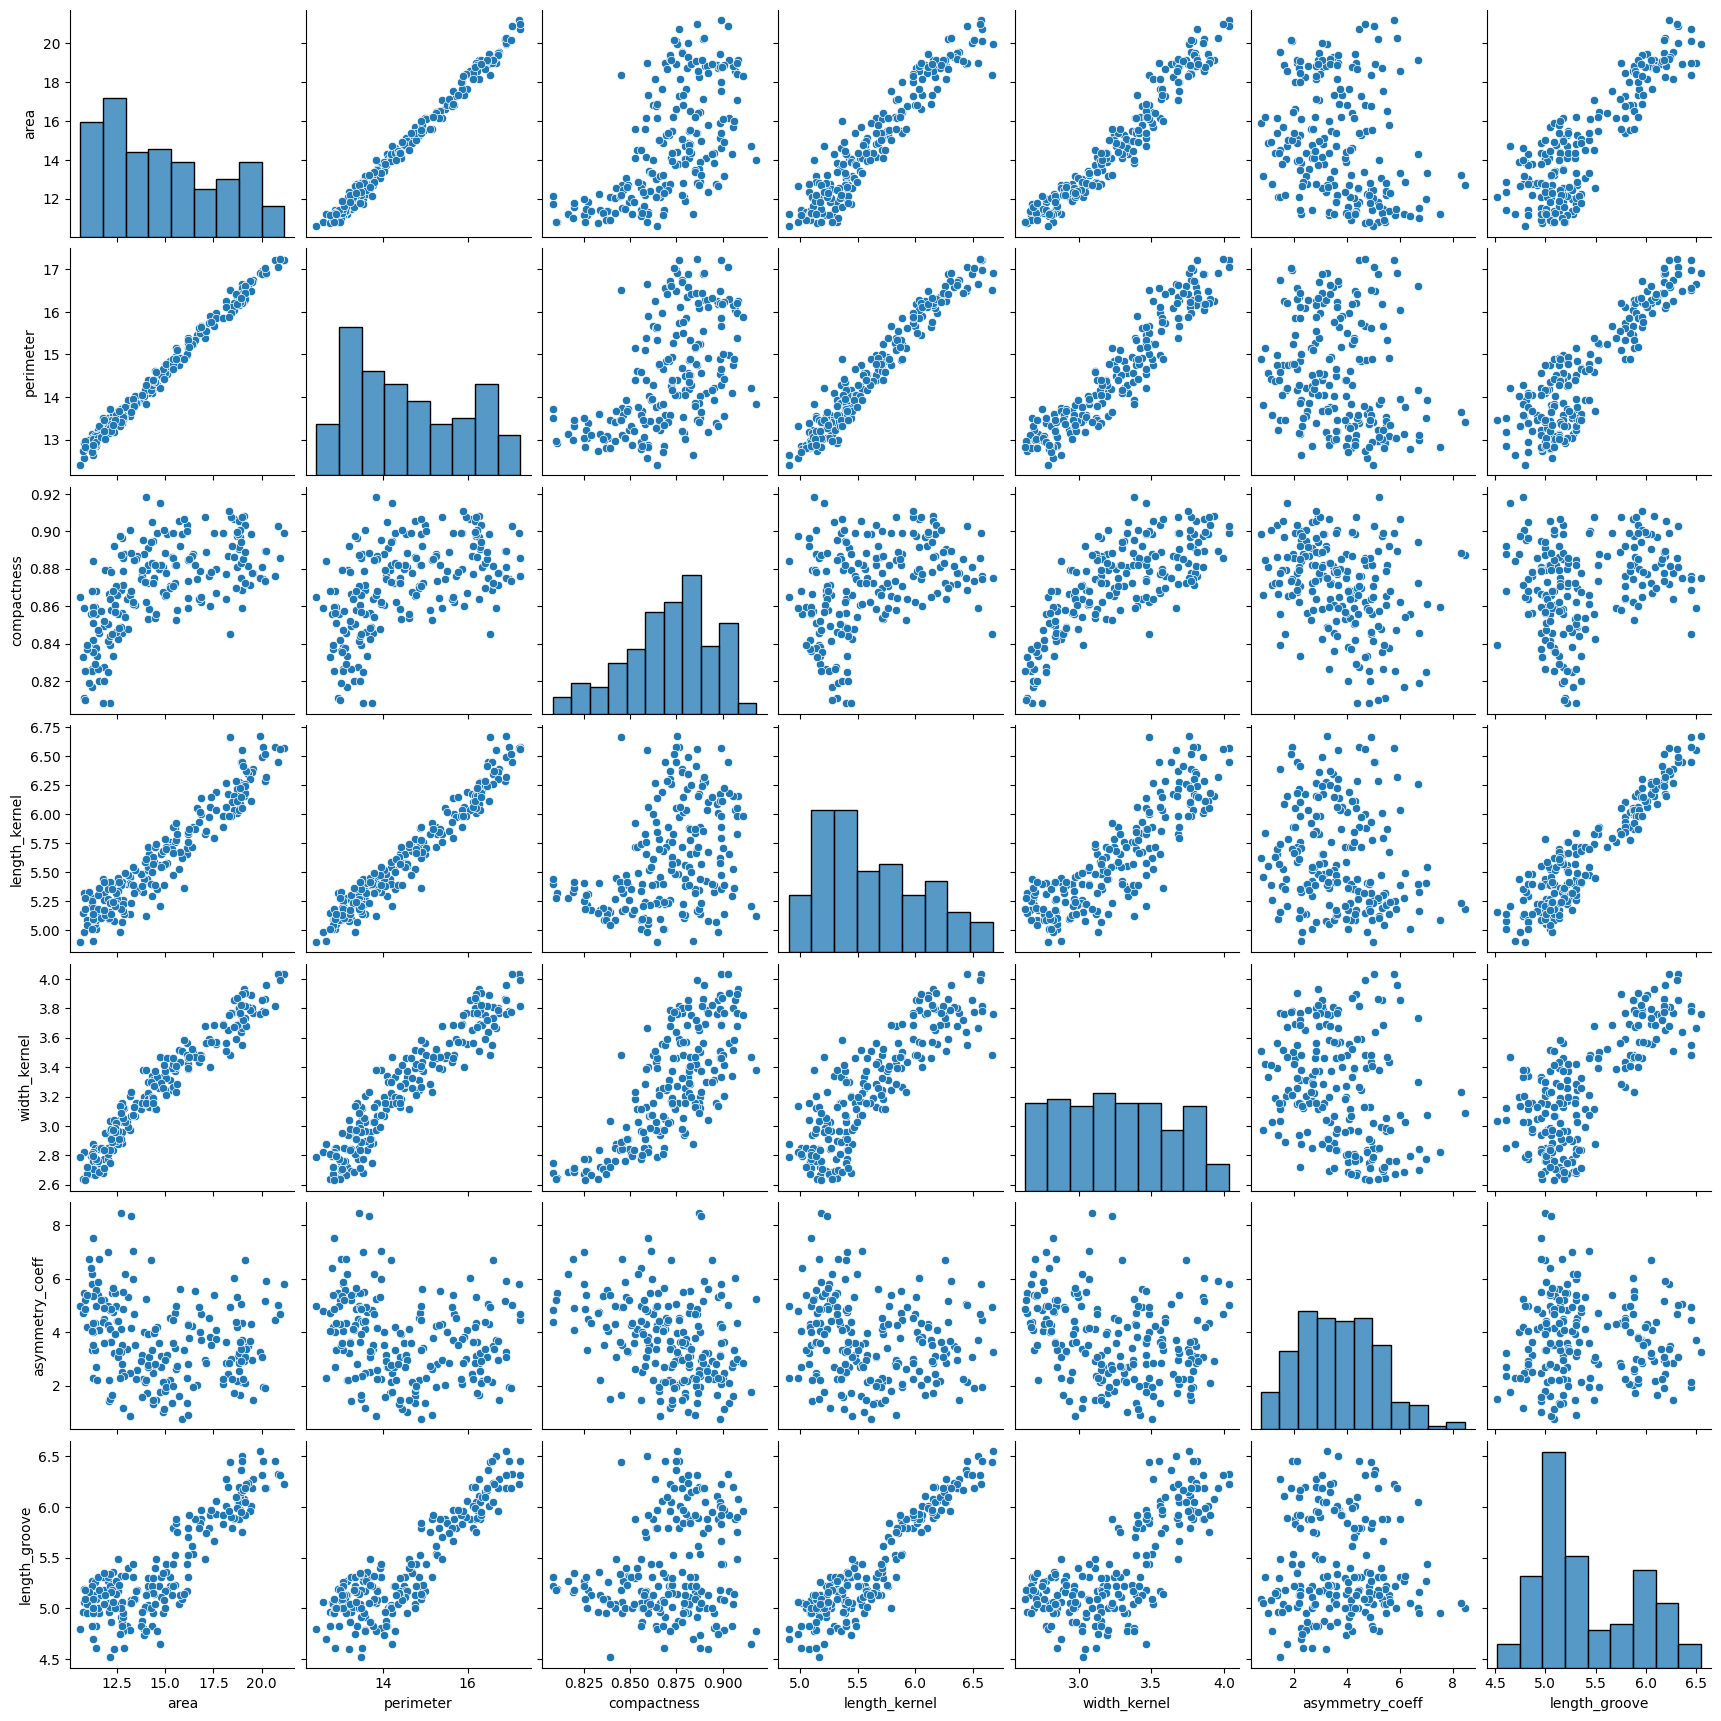

In [77]:
sns.pairplot(X)
plt.show()

In [78]:
from helper.selection import scan_k_metrics

seeds_metrics = scan_k_metrics(X=X_seeds_std, ks=range(2, 8), random_state=42)

display(seeds_metrics)

,k,inertia,silhouette,ch,db
0,2,659.935777,0.461466,255.317812,0.810186
1,3,430.816528,0.402437,249.654974,0.922088
2,4,371.653144,0.329197,202.930659,1.062899
3,5,336.243099,0.266052,172.806643,1.287628
4,6,296.325608,0.244537,161.598977,1.338337
5,7,264.905709,0.255544,153.912715,1.300333


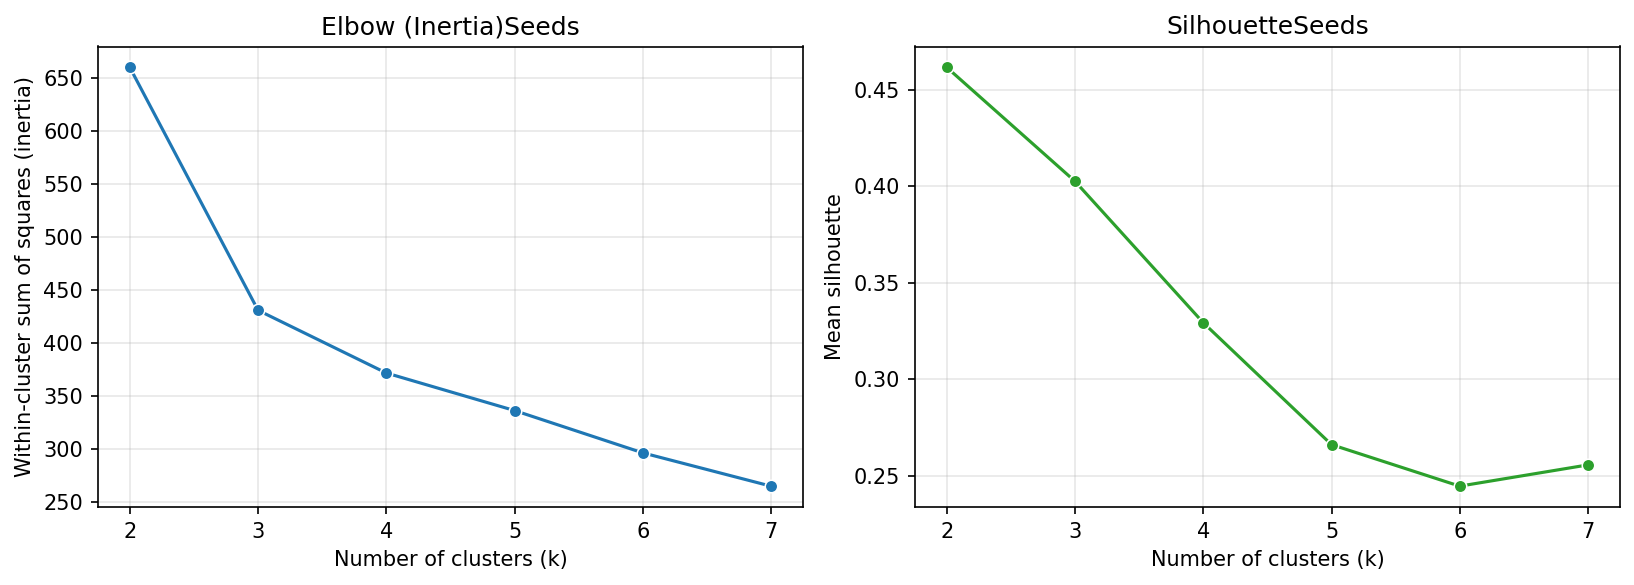

In [79]:
from helper.plotting import plot_elbow_silhouette

plot_elbow_silhouette(seeds_metrics, "Seeds")
plt.show()

In [80]:
from helper.report import k_report

r2_seeds = k_report(X_seeds_std, k=2, true_labels=y_true)
r3_seeds = k_report(X_seeds_std, k=3, true_labels=y_true)
r4_seeds = k_report(X_seeds_std, k=4, true_labels=y_true)

print({k: v for k, v in r2_seeds.items() if k != "model"})
print({k: v for k, v in r3_seeds.items() if k != "model"})
print({k: v for k, v in r4_seeds.items() if k != "model"})

{'k': 2, 'inertia': 659.935776644357, 'silhouette': 0.46146579826821466, 'CH': 255.3178118554645, 'DB': 0.8101856396961451, 'ARI': 0.5074767556450577, 'AMI': 0.5965282022051229, 'NMI': 0.5987304258201084}
{'k': 3, 'inertia': 430.81652834345675, 'silhouette': 0.4024370101867174, 'CH': 249.65497431126064, 'DB': 0.9220878143202835, 'ARI': 0.7971900801193832, 'AMI': 0.7476785330956146, 'NMI': 0.7498948838399828}
{'k': 4, 'inertia': 371.65314399951626, 'silhouette': 0.3291966792017614, 'CH': 202.930659038, 'DB': 1.062899481872673, 'ARI': 0.6388222022666139, 'AMI': 0.6441612534143376, 'NMI': 0.6484031171265918}


In [81]:
from sklearn.metrics import silhouette_score

# Suppose elbow and silhouette both support k=3
k = 3
kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_seeds_std)

print("Inertia:", kmeans.inertia_)
print("Silhouette:", silhouette_score(X_seeds_std, labels))

Inertia: 430.81652834345675
Silhouette: 0.4024370101867174


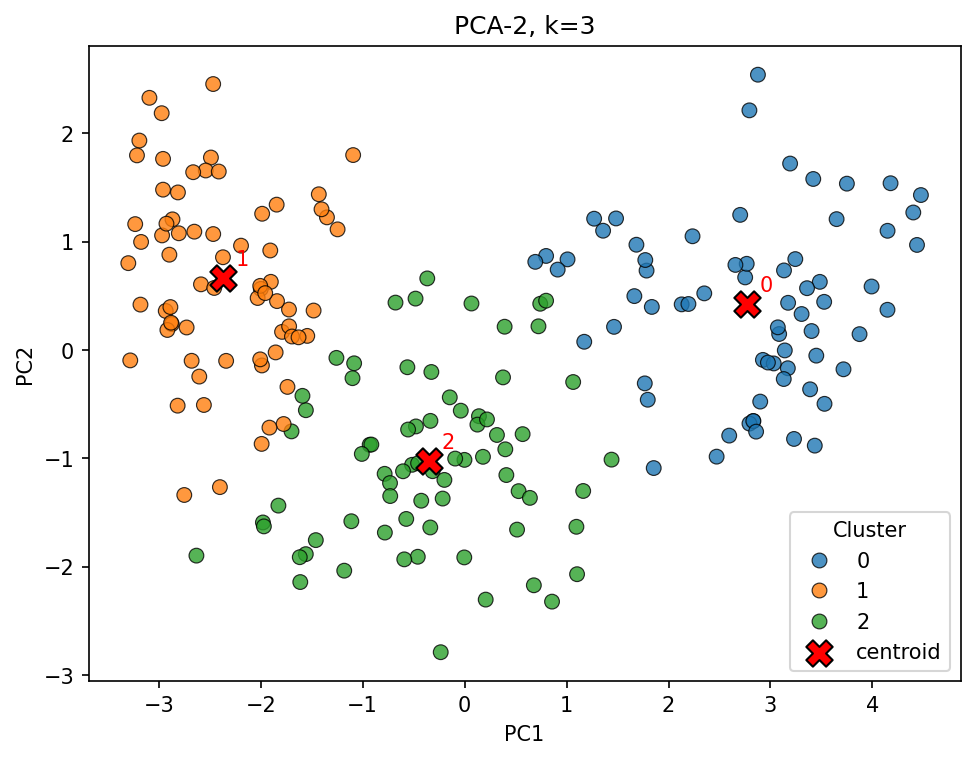

In [82]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(X_seeds_std, kmeans, title="PCA-2, k=3")
plt.show()

In [83]:
df_eval = pd.DataFrame({"Cluster": labels, "Variety": y_true})
ct = pd.crosstab(df_eval.Cluster, df_eval.Variety)
display(ct)

Variety,1,2,3
Cluster,,,
0,2,66,0
1,4,0,65
2,64,4,5


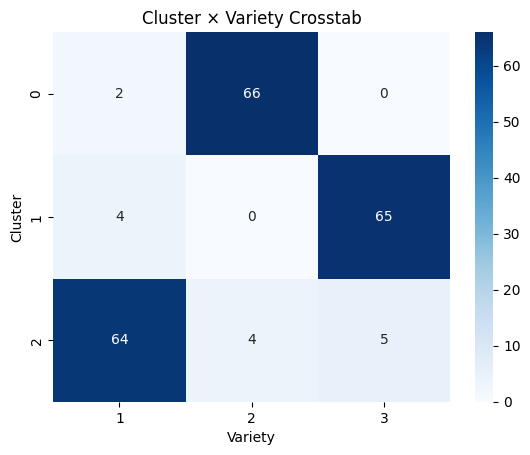

In [84]:
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster × Variety Crosstab")
plt.show()

In [85]:
# Row-wise proportions for easier interpretation
ct_row = ct.div(ct.sum(axis=1), axis=0).round(2)
display(ct_row)

Variety,1,2,3
Cluster,,,
0,0.03,0.97,0.00
1,0.06,0.00,0.94
2,0.88,0.05,0.07


In [86]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_true, labels)
nmi = normalized_mutual_info_score(y_true, labels)
print(f"ARI = {ari:.3f} | NMI = {nmi:.3f}")

ARI = 0.797 | NMI = 0.750


## **Transforming Features for Better Clustering (Rebuilt Lecture)**

### **1. The Real Problem**

K-Means clustering minimises the within-cluster sum of squared *Euclidean* distances:

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2
$$

where:

* $x_i$ = observation vector,
* $\mu_k$ = centroid of cluster $C_k$.

This formula treats **each feature equally in raw numerical scale**.
Therefore, if one feature (say, *proline*) has values in the thousands and another (say, *malic acid*) varies around 1, the larger-scaled feature dominates the distance computation.
In other words:

> In K-Means, **variance equals influence**.

That's why scaling isn't just cosmetic; it fundamentally changes the cluster geometry.


### **2. Dataset — The Real Piedmont Wines**

The *Wine* dataset from UCI Machine Learning Repository:

* 178 samples from *Barolo*, *Grignolino*, and *Barbera* wines.
* 13 continuous features from chemical analysis.

```python
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X = wine.data
y_true = wine.target
feature_names = wine.feature_names
print(X.head())
print(wine.target_names)
```

This dataset is the canonical example of scaling issues because *proline*’s variance is 5–6 orders of magnitude higher than most features.

### **3. Step One — Quantifying the Problem**

Before doing anything, measure the **spread** (variance and range) of each feature.

```python
X.describe().loc[['mean', 'std', 'min', 'max']].T.sort_values('std', ascending=False)
```

You’ll see:

* `proline` std ≈ 518
* `flavanoids` std ≈ 1
* `color_intensity` std ≈ 2

A single feature (proline) swamps the geometry.
Let’s confirm that visually.

```python
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=X[['proline', 'alcohol', 'flavanoids', 'color_intensity']])
plt.title("Unscaled Feature Distributions (notice different magnitudes)")
plt.show()
```

If you cluster this dataset **without scaling**, the algorithm primarily separates wines by *proline*, ignoring all subtler dimensions.

### **4. Step Two — Clustering Without Scaling**

```python
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

kmeans_raw = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_raw = kmeans_raw.fit_predict(X)

print("Inertia:", kmeans_raw.inertia_)
print("Silhouette:", silhouette_score(X, labels_raw))
print("ARI:", adjusted_rand_score(y_true, labels_raw))
```

> You’ll likely get **ARI ≈ 0.2–0.3** — meaning almost random alignment with true varieties.

Let’s also examine cross-tabulation.

```python
pd.crosstab(labels_raw, y_true)
```

It will look chaotic, like DataCamp’s example (`Barbera` and `Grignolino` tangled).


## **5. Step Three — Standardising Features**

Now apply **StandardScaler**, which transforms each feature:

$$
z = \frac{x - \bar{x}}{s}
$$

where $\bar{x}$ is the mean and $s$ is the standard deviation.

After scaling, each column has mean 0 and variance 1.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
X_scaled_df.describe().loc[['mean', 'std']].T
```

All means ≈ 0, stds ≈ 1 — now features contribute equally to distance.

### **6. Step Four — Scaled Clustering**

```python
kmeans_scaled = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

print("Inertia:", kmeans_scaled.inertia_)
print("Silhouette:", silhouette_score(X_scaled, labels_scaled))
print("ARI:", adjusted_rand_score(y_true, labels_scaled))
```

> You’ll now see **ARI ≈ 0.9**, **Silhouette ≈ 0.55**, a dramatic improvement.

```python
pd.crosstab(labels_scaled, y_true)
```

You’ll observe near-perfect alignment of clusters with varieties — the effect of equalised feature influence.

### **7. Step Five — Pipelines for Elegance**

The scaling + clustering pattern appears constantly in machine learning.
Rather than calling `.fit_transform()` manually, scikit-learn offers **pipelines** that automate the flow of data through sequential steps.

```python
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=3, n_init='auto', random_state=42))
pipeline.fit(X)

labels_pipe = pipeline.predict(X)
print("ARI:", adjusted_rand_score(y_true, labels_pipe))
```

The pipeline:

1. Fits the scaler on `X` and transforms it;
2. Passes the scaled data into KMeans;
3. Allows you to `fit()` and `predict()` with the same syntax as a single estimator.

### **8. Step Six — Visual Comparison**

To appreciate scaling’s geometric impact:

```python
from sklearn.decomposition import PCA

def plot_pca(X_data, labels, title):
    pca = PCA(n_components=2)
    Z = pca.fit_transform(X_data)
    sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=labels, palette="Set2")
    plt.title(title)
    plt.show()

plot_pca(X, labels_raw, "PCA – Raw Features")
plot_pca(X_scaled, labels_scaled, "PCA – Scaled Features")
```

In the *raw* plot, clusters smear along one high-variance axis (proline).
In the *scaled* plot, structure reappears, separating three distinct, compact clusters.


### **9. Step Seven — Quantitative Comparison**

| Metric     | Raw   | Scaled     |
| ---------- | ----- | ---------- |
| Inertia    | High  | Much lower |
| Silhouette | ~0.25 | **~0.55**  |
| ARI        | 0.25  | **0.9**    |
| NMI        | 0.35  | **0.88**   |

> Feature standardisation didn’t just make the plot “look better”; it restored meaningful geometry.


### **10. Discussion**

#### **Why this matters conceptually**

* KMeans assumes **isotropic** (spherical) clusters in Euclidean space.
* Scaling ensures isotropy across features, preventing any dimension from dominating.
* In many real datasets (especially chemical, physical, or economic), magnitudes differ drastically, so scaling is not optional — it’s *a precondition* for meaningful distance-based learning.

#### **When not to scale**

* If your features are already **dimensionless ratios** or share the same physical units (e.g., all percentages).
* Or when interpretability in the original scale matters (e.g., clustering income levels).


In [87]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X = wine.data
X_raw = X.copy()
y_true = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

## **Tasks**

### **Task 1 – Quantify the Scaling Problem**

Compute and inspect the variance and range of each feature.
Identify which variables are most likely to dominate K-Means distance computations.


In [88]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


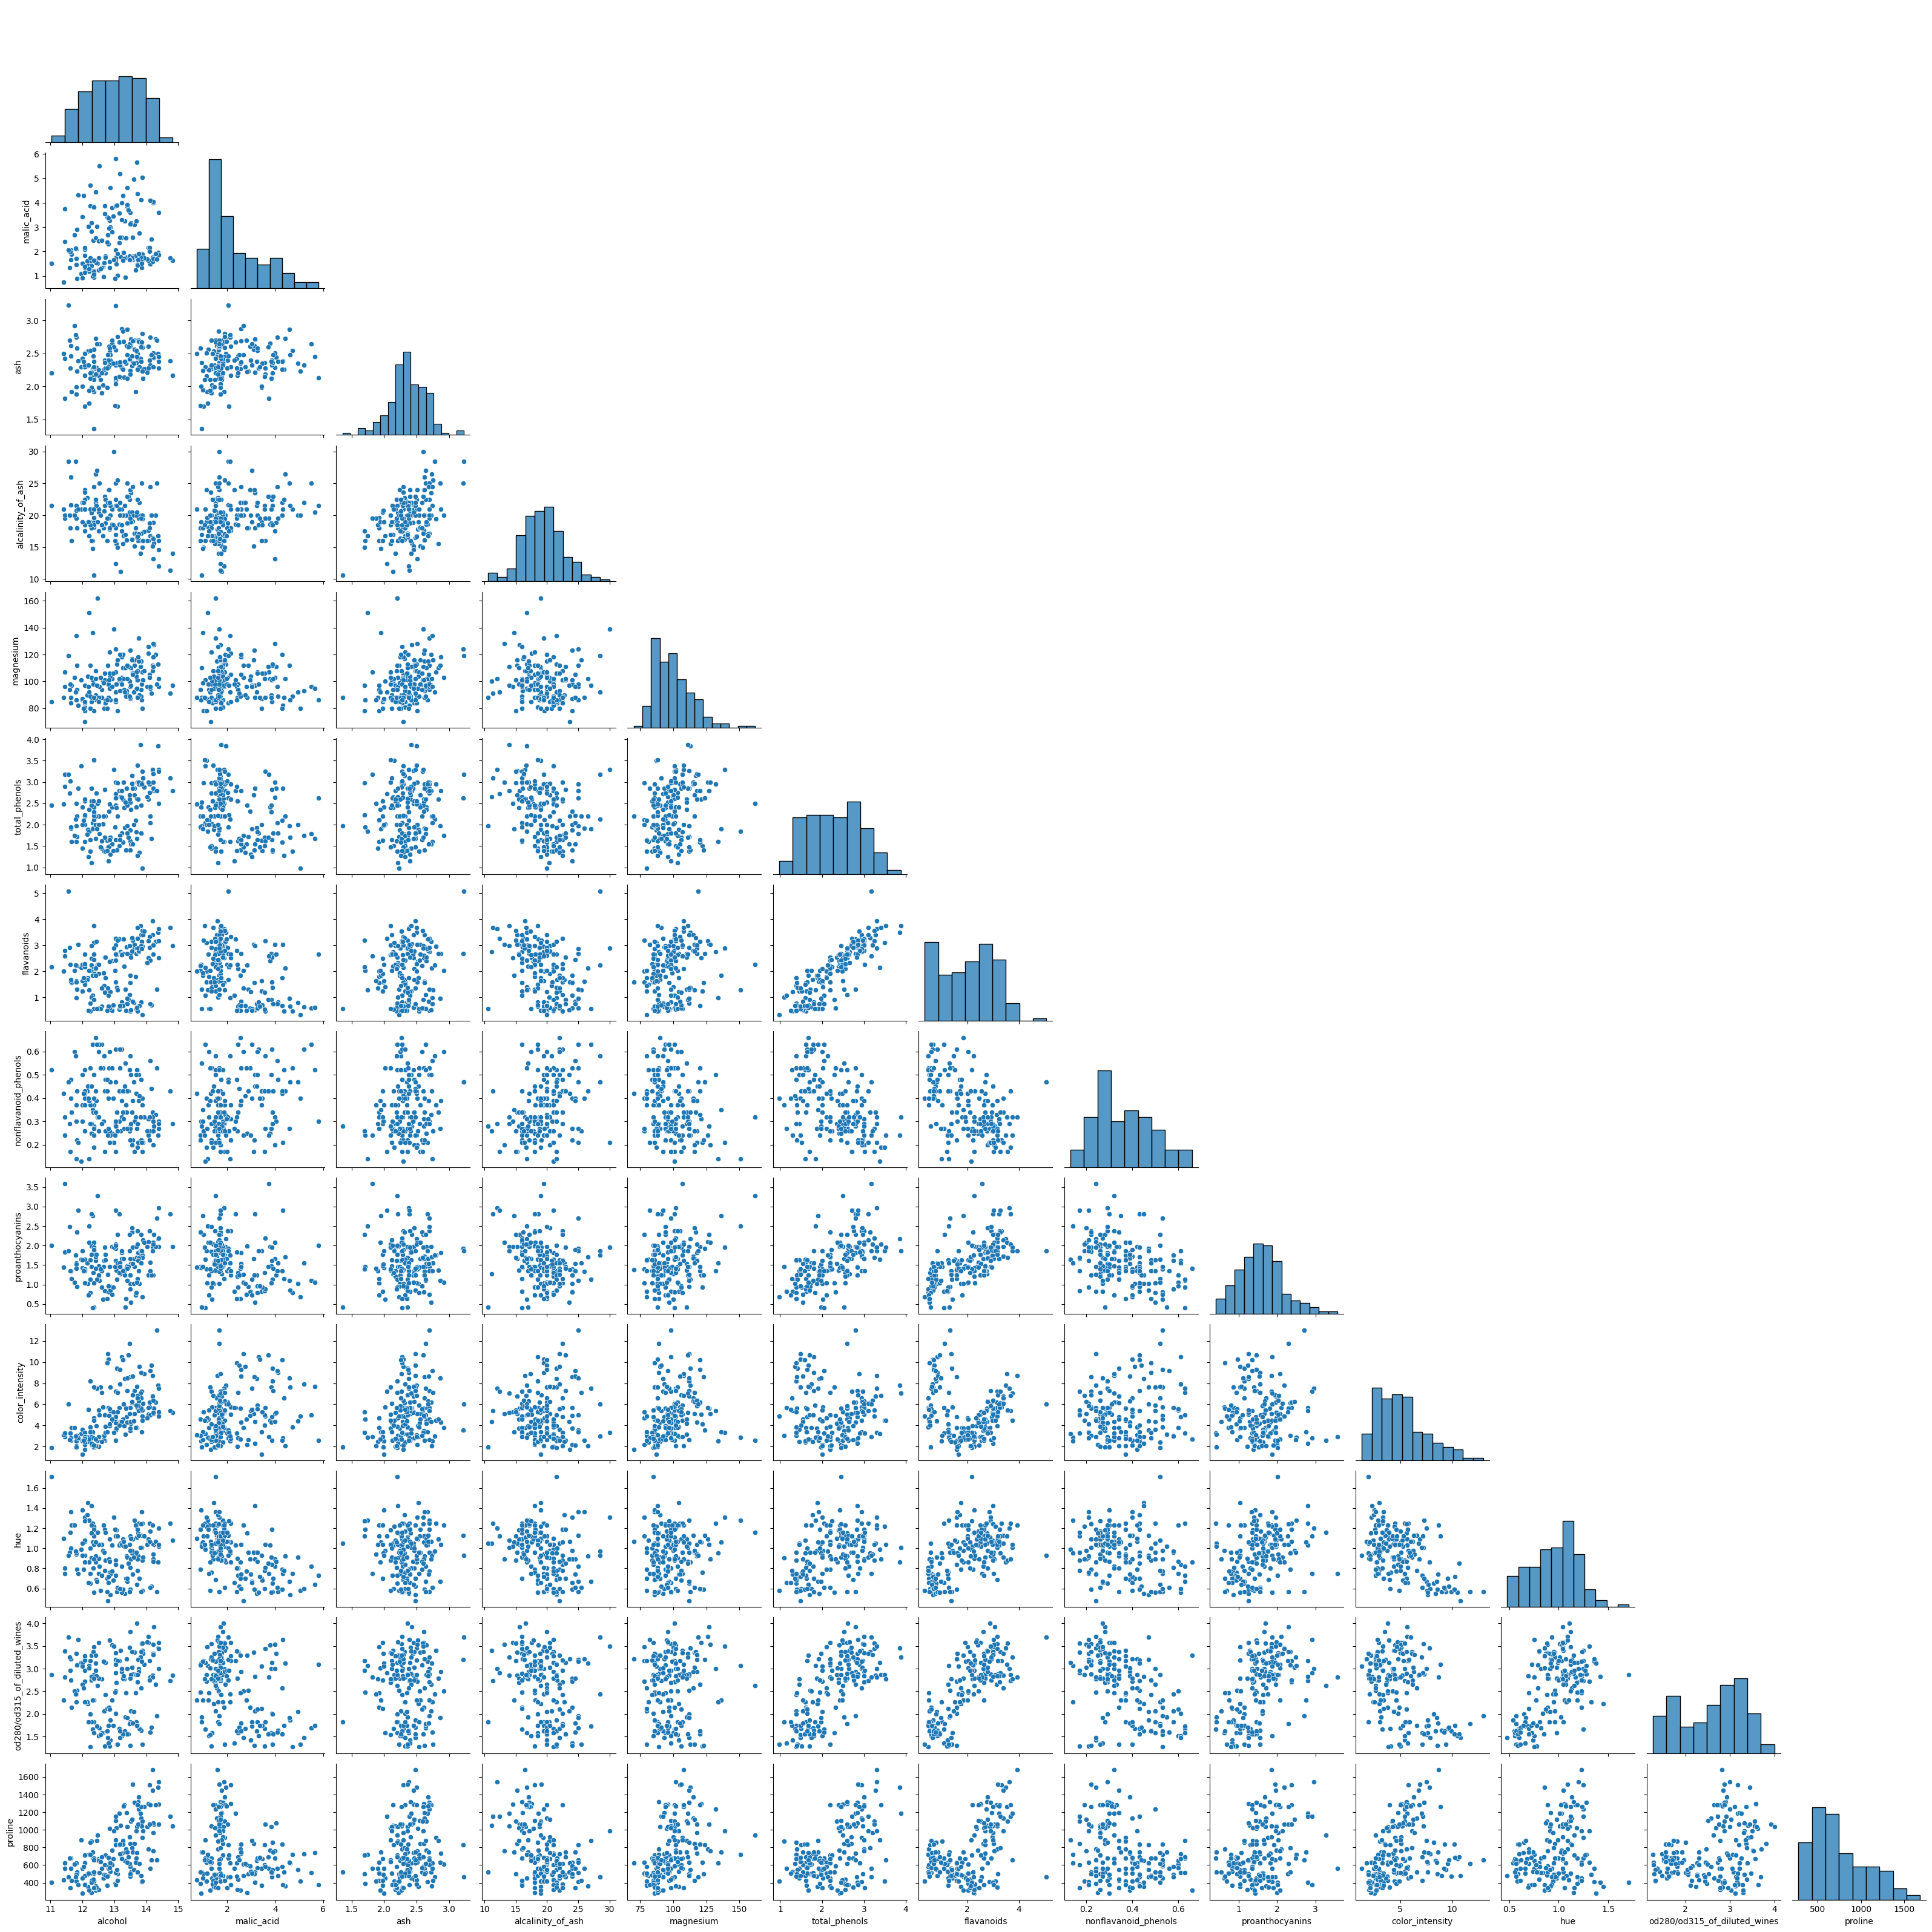

In [89]:
sns.pairplot(X, corner=True)
plt.show()

In [90]:
X.var()

alcohol                             0.659062
malic_acid                          1.248015
ash                                 0.075265
alcalinity_of_ash                  11.152686
magnesium                         203.989335
total_phenols                       0.391690
flavanoids                          0.997719
nonflavanoid_phenols                0.015489
proanthocyanins                     0.327595
color_intensity                     5.374449
hue                                 0.052245
od280/od315_of_diluted_wines        0.504086
proline                         99166.717355
dtype: float64

### **Task 2 – Baseline Clustering (Unscaled)**

Fit K-Means (k=3) directly on the raw data.
Assess cluster quality using at least **two internal metrics** (e.g. inertia, silhouette) and **one external metric** (ARI or NMI).
Show the cross-tabulation between clusters and true classes.

Deliverables:

* Metric table (inertia, silhouette, ARI/NMI).
* Crosstab visualisation (heatmap or DataFrame).

In [91]:
from sklearn.cluster import KMeans

km_raw = KMeans(n_clusters=3)
km_raw.fit(X_raw)
labels_raw = km_raw.predict(X_raw)

In [92]:
from helper.report import k_report

unscaled_r3 = k_report(X_raw, k=3, true_labels=y_true)
unscaled_r3 = {k: v for k, v in unscaled_r3.items() if k != "model"}

print(f"Unscaled: {unscaled_r3}")

Unscaled: {'k': 3, 'inertia': 2633555.3324093386, 'silhouette': 0.5595823478987215, 'CH': 497.00487620805814, 'DB': 0.549557597464291, 'ARI': 0.3517721516862617, 'AMI': 0.4167590924073939, 'NMI': 0.423309269344735}


c:\Users\jhonm\.conda\envs\datacamp\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


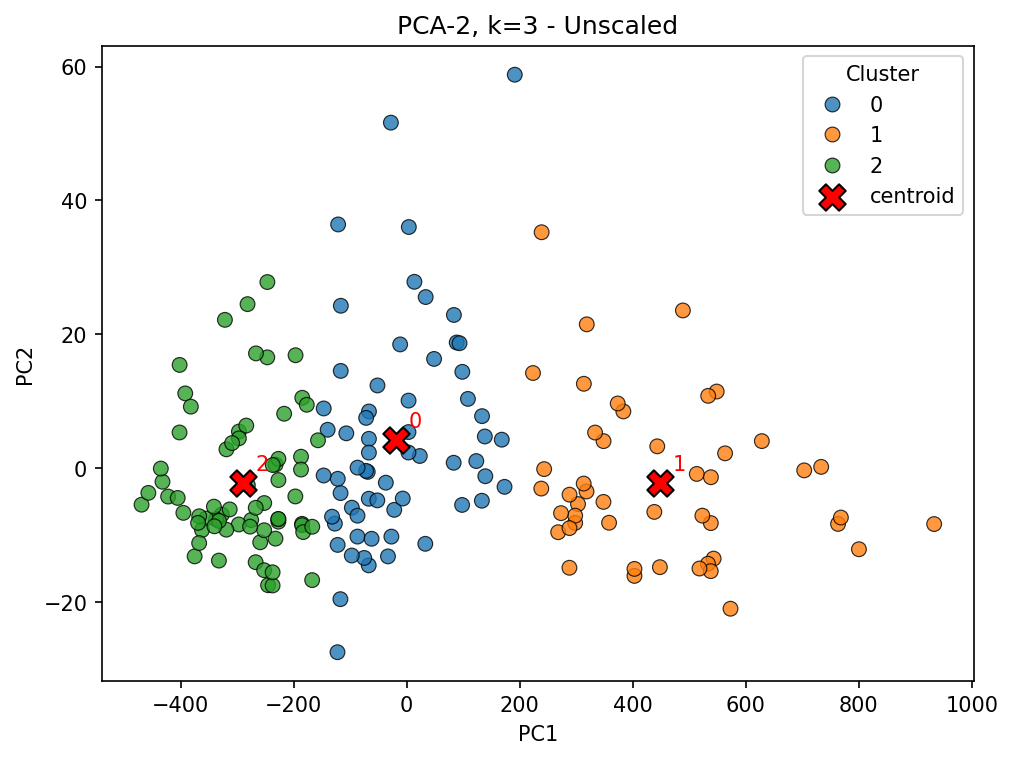

In [93]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(X_raw, km_raw, title="PCA-2, k=3 - Unscaled")
plt.show()

### **Task 3 – Feature Standardisation**

Standardise features using an appropriate scaler (you choose which, but justify it).
Then rerun the same clustering procedure.

Deliverables:

* Scaler choice + reasoning.
* New metrics and crosstab.
* Quantitative and qualitative comparison to the unscaled results.

In [94]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# The wine dataset has features on different scales; StandardScaler is appropriate
# to equalise mean and variance before distance-based clustering.
scaler_wine = StandardScaler()
km_wine = KMeans(n_clusters=3, random_state=42)

X_wine_std = scaler.fit_transform(X)
km_wine.fit(X_wine_std)
labels = km_wine.predict(X_wine_std)

In [95]:
from helper.report import k_report

r3_wine = k_report(X_wine_std, k=3, true_labels=y_true)

scaled_r3 = {k: v for k, v in r3_wine.items() if k != "model"}
print(f"Unscaled: {unscaled_r3}")
print(f"Scaled: {scaled_r3}")

Unscaled: {'k': 3, 'inertia': 2633555.3324093386, 'silhouette': 0.5595823478987215, 'CH': 497.00487620805814, 'DB': 0.549557597464291, 'ARI': 0.3517721516862617, 'AMI': 0.4167590924073939, 'NMI': 0.423309269344735}
Scaled: {'k': 3, 'inertia': 1277.928488844642, 'silhouette': 0.2848589191898987, 'CH': 70.94000800315118, 'DB': 1.3891879777181648, 'ARI': 0.8974949815093207, 'AMI': 0.874579440437926, 'NMI': 0.8758935341223069}


### Key Takeaways

1. **Never compare inertia across different scalings** - the units are different!
2. **Trust external validation** (ARI/AMI) over internal metrics when you have ground truth
3. **Scaling is CRITICAL** for K-means when features have different units/scales
4. **The scaled clustering is actually excellent** - those ~0.90 scores are very good!

### **Task 4 – Pipeline Construction**

Implement the entire transformation + clustering process as a **scikit-learn pipeline**.
Verify that the results match your previous step.

Deliverables:

* A clean, reusable pipeline.

In [96]:
from sklearn.pipeline import make_pipeline

pipe_wine = make_pipeline(scaler_wine, km_wine)

### **Task 5 – Visual Evidence**

Project the data into two dimensions (PCA, t-SNE, or UMAP).
Compare geometric structure of raw vs. scaled features.

Deliverables:

* Two scatterplots (before and after scaling).
* A concise written reflection:
  “How does scaling change the geometric interpretation of distance and shape?”

c:\Users\jhonm\.conda\envs\datacamp\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


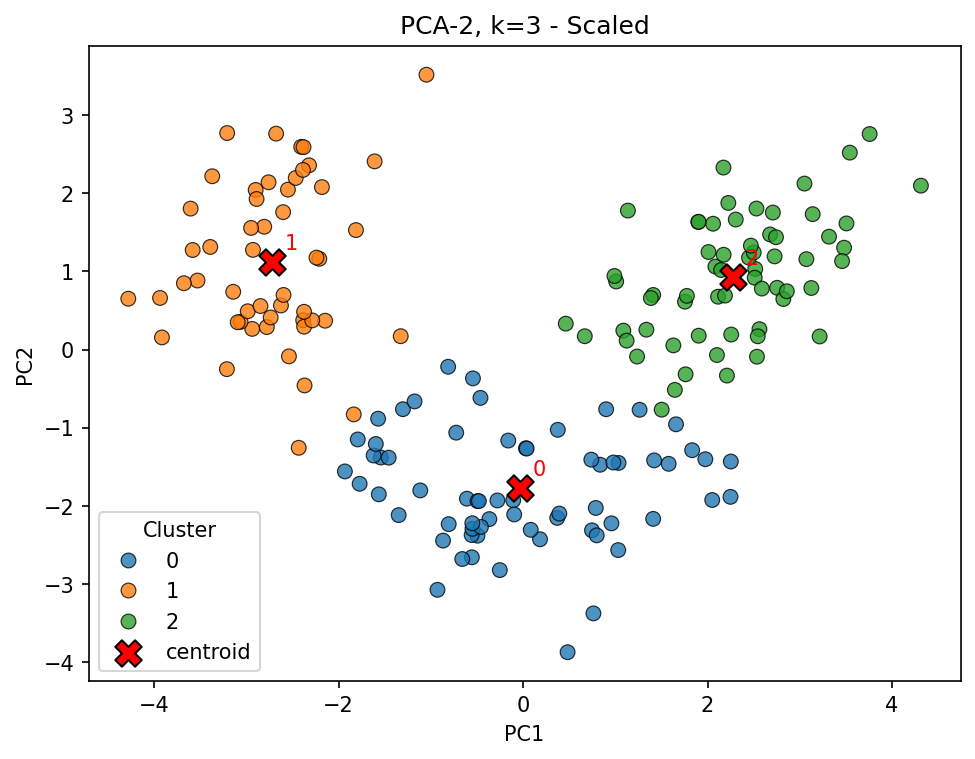

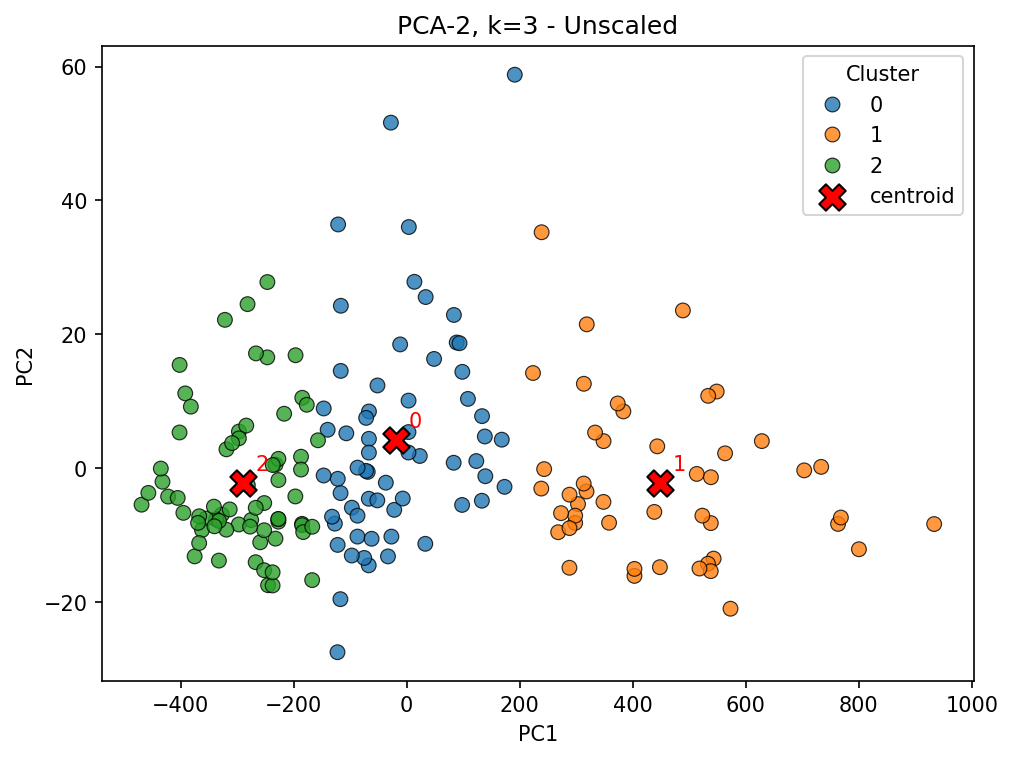

In [97]:
from helper.plotting import plot_kmeans_pca2

plot_kmeans_pca2(X_wine_std, km_wine, title="PCA-2, k=3 - Scaled")
plot_kmeans_pca2(X_raw, km_raw, title="PCA-2, k=3 - Unscaled")
plt.show()

### **Task 6 – Comparative Experiment**

Repeat the pipeline using **at least one alternative scaling technique** (`MinMaxScaler`, `RobustScaler`, or `Normalizer`).
Analyse whether the cluster assignments or metrics change meaningfully.

Deliverables:

* Comparative table (scaler, silhouette, ARI/NMI, inertia).
* Your interpretation of the most suitable scaling strategy for this dataset.

> it doesn't make any sense to use any of those scaling techniques, after reading the official documentation it's crystal clear when and why I should use each.

### 1) Why hierarchical clustering is useful

K-means gives you one flat partition for a chosen (k). In many domains, the structure is **nested**: fine-grained groups within broader families (e.g., grape varieties within regions; product segments within markets). **Agglomerative hierarchical clustering (HC)** builds exactly such a *nested* sequence of merges. The output—the **dendrogram**—is a compact visual audit of “who joined whom, and at what dissimilarity”.

Good uses in practice:

* exploratory grouping of countries by macro indicators, customers by baskets, genes by expression profiles, or assets by co-movement;
* **feature** clustering (group strongly related variables before modelling);
* transparent, meeting-friendly graphics where the audience wants to *see* relationships.
### 2) Foundations: distances, linkages, and the algorithm

Let $X=\{x_1,\dots,x_n\}$ be your samples in $\mathbb{R}^d$. Choose a *dissimilarity* $D(x_i,x_j)$ (Euclidean by default; cosine/correlation for "shape" similarity; Gower for mixed types). Define a **linkage** $L(A,B)$ that turns two clusters $A,B\subset X$ into a single number.

Common linkages:

* **Single**: $L_{\min}(A,B)=\min_{a\in A,b\in B} D(a,b)$ (prone to chaining).
* **Complete**: $L_{\max}(A,B)=\max_{a\in A,b\in B} D(a,b)$ (compact, sensitive to outliers).
* **Average/UPGMA**: mean pairwise distance across $A\times B$.
* **Ward**: merges $A,B$ that **minimise the increase in within-cluster SSE**:
  $$
  \Delta(A,B) = \frac{|A||B|}{|A|+|B|}\|\mu_A-\mu_B\|_2^2,
  $$
  where $\mu_A$ is the mean of $A$. Ward **requires Euclidean geometry** and tends to yield spherical, k-means-like groups.

**Agglomerative algorithm (sketch)**

1. Start with $n$ singleton clusters.
2. Repeatedly merge the pair $(A,B)$ with smallest $L(A,B)$.
3. Record the merge "height" (the value of $L$ at merge time). Continue until one cluster remains.

Complexity: storing the distance structure is $O(n^2)$ memory; with modern implementations, time is $O(n^2)$. This is not a big-data method; subsample or pre-embed for $n\gtrsim 10^4$.

### 3) How to read a dendrogram (and what *not* to read into it)

* The **height** where two branches meet is the dissimilarity at which those clusters first become indistinguishable, given your metric and linkage.
* The **x-axis order is arbitrary** (leaves can be flipped at each merge without changing the tree).
* Cutting the tree at height (h) yields a **flat partition**. Alternatively, specify the **number of clusters** to cut.
* Do not interpret heights as probabilities, p-values, or “strength of evidence”. They are pure geometry.

### 4) Pre-processing and metric choice

* **Standardise** features before Euclidean distance; otherwise high-variance columns dominate.
* Use **cosine/correlation** dissimilarity when *direction/shape* matters more than magnitude (e.g., time-series co-movement across entities).
* For mixed numeric/categorical data: compute **Gower** distances (via `gower` package) or design a domain-specific similarity.

### 5) Python—clean, readable patterns


#### 5.1 Wine (UCI, via scikit-learn): Ward linkage on scaled chemistry

```python
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from scipy.cluster import hierarchy as sch

# data 
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
labels_true = pd.Series(y).map(dict(enumerate(wine.target_names)))

# scale for Euclidean geometry (Ward) 
Z = StandardScaler().fit_transform(X)

# Ward internally uses Euclidean metric on the raw observations; pdist is optional here.
merges = linkage(Z, method="ward")

# dendrogram
fig, ax = plt.subplots(figsize=(10, 5), dpi=130)
dendrogram(
    merges,
    labels=labels_true.index.astype(str).to_numpy(),  # sample indices (short)
    leaf_rotation=90, leaf_font_size=7, ax=ax,
)
ax.set_title("Wine samples – Ward linkage on scaled features")
ax.set_ylabel("Dissimilarity (Ward)")
plt.tight_layout(); plt.show()

# choose a flat partition: e.g. k=3 to compare to varieties
k = 3
labels_hc = fcluster(merges, t=k, criterion="maxclust")

# external audit (only because Wine has ground truth) 
ari = adjusted_rand_score(y, labels_hc)
nmi = normalized_mutual_info_score(y, labels_hc)
print(f"ARI={ari:.3f}  NMI={nmi:.3f}")

# fidelity of the tree itself (cophenetic correlation)
coph_dists, coph_links = sch.cophenet(merges, pdist(Z, metric="euclidean"))
print(f"Cophenetic correlation (tree vs. pairwise distances): {coph_dists:.3f}")

# feature clustering variant (cluster columns by correlation)
corr = X.corr()
sns.clustermap(
    corr, center=0, cmap="vlag", linewidths=.2,
    row_cluster=True, col_cluster=True, figsize=(8, 8)
)
plt.show()
```

**What to look for.** With Ward on scaled chemistry, a cut at (k=3) typically aligns well with varieties. The **cophenetic correlation** quantifies how faithfully the tree preserves pairwise dissimilarities (closer to 1 is better). The **clustermap** demonstrates hierarchical clustering of *features*—handy for spotting redundant blocks before modelling.

#### 5.2 Penguins (seaborn): effect of linkage choice

```python
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

peng = sns.load_dataset("penguins").dropna()
Xpeng = peng[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]].to_numpy()
ypeng = peng["species"].to_numpy()

Xpeng_z = StandardScaler().fit_transform(Xpeng)

# compare linkages on the same metric 
for method in ["single", "complete", "average", "ward"]:
    Z = linkage(Xpeng_z, method=method)  # Euclidean metric by default
    labs = fcluster(Z, t=3, criterion="maxclust")
    ari = adjusted_rand_score(ypeng, labs)
    print(f"{method:>8}  ARI={ari:.3f}")

    fig, ax = plt.subplots(figsize=(9, 4), dpi=130)
    dendrogram(Z, no_labels=True, ax=ax)
    ax.set_title(f"Penguins – {method} linkage (scaled features)")
    ax.set_ylabel("Dissimilarity")
    plt.tight_layout(); plt.show()
```

You will generally see **single** succumb to chaining (long thin branches), **complete** produce very compact clusters but split more aggressively, **average** behave moderately, and **Ward** mirror k-means-like geometry. The external ARI validates which picture aligns with species.

### 6) Cutting trees responsibly

“Where do I cut?” is not answered by the dendrogram alone.

* **By number of clusters**: `fcluster(Z, t=k, criterion="maxclust")`.
* **By height**: choose a threshold (h); everything merged above that stays separate below.
* **By inconsistency** (SciPy’s `inconsistent`): cut branches that are much taller than their local neighbourhood.
* **By external or internal metrics**: compute silhouette/DB/CH on the flat assignments across a grid of cut levels, then choose a principled point (and report it).

```python
from sklearn.metrics import silhouette_score

def silhouette_over_heights(Z, X, heights):
    out = []
    for h in heights:
        labs = fcluster(Z, t=h, criterion="distance")
        if len(np.unique(labs))>1:
            out.append((h, silhouette_score(X, labs)))
    return pd.DataFrame(out, columns=["height","silhouette"])

Z_wine = linkage(StandardScaler().fit_transform(X), method="ward")
heights = np.linspace(5, 50, 20)  # sensible range depends on your data
sil_df = silhouette_over_heights(Z_wine, StandardScaler().fit_transform(X), heights)
print(sil_df.sort_values("silhouette", ascending=False).head())
```

### 7) Choosing metric and linkage for real problems

* **If your notion of similarity is “parallel movement regardless of scale”** (e.g., daily log-return *shape* for equities), use **cosine** or **correlation distance** with **average/complete** linkage. Do *not* use Ward.

  ```python
  D = pdist(returns.T, metric="correlation")   # stocks × time
  Z = linkage(D, method="average")             # pass precomputed distances
  ```
* **If your notion is “overall Euclidean closeness across many comparable features”**, scale then use **Ward**.
* **If you care about outliers** (you do): single is fragile; complete is robust but can split multi-modal clusters; average is often a decent compromise.

### 8) Relation to t-SNE (and a sober warning)

t-SNE is not a clustering algorithm. It is a *non-linear embedding* that arranges points in 2-D using a perplexity-controlled local similarity. t-SNE **distorts global geometry on purpose** to reveal local neighbourhoods; distances between far-apart blobs are not meaningful. If you plot t-SNE and then draw clusters around blobs, be explicit that the “clusters” are a visual heuristic. When you need a partition, compute it from the **original space** and use t-SNE only for illustration.

### 9) Anti-patterns and pitfalls

* Interpreting the dendrogram x-order as meaningful.
* Using **Ward with non-Euclidean metrics** (mathematically inconsistent).
* Skipping scaling for Euclidean distances.
* Reading heights as statistical significance.
* Over-crowded dendrograms (hundreds of leaves) that nobody can read—subsample, or cluster the *centroids* of a prior k-means.

### 10) A compact helper you can reuse

When you need a clean summary in a notebook:

```python
from dataclasses import dataclass
@dataclass
class HCReport:
    method: str
    metric: str
    ari: float | None
    nmi: float | None

def hc_fit_evaluate(X: np.ndarray, *, method="ward", metric="euclidean",
                    labels_true: np.ndarray | None=None, cut="maxclust", t=3) -> HCReport:
    """
    Fit hierarchical clustering and (optionally) evaluate against labels_true.
    """
    # For Ward, metric must be Euclidean on observations (not on a distance matrix).
    if method == "ward" and metric != "euclidean":
        raise ValueError("Ward requires Euclidean metric on raw observations.")
    Z = linkage(X, method=method, metric=metric)
    labs = fcluster(Z, t=t, criterion=cut)
    ari = adjusted_rand_score(labels_true, labs) if labels_true is not None else None
    nmi = normalized_mutual_info_score(labels_true, labs) if labels_true is not None else None
    return HCReport(method, metric, ari, nmi)
```

Example:

```python
Xz = StandardScaler().fit_transform(X)
print(hc_fit_evaluate(Xz, method="ward", labels_true=y, t=3))
print(hc_fit_evaluate(Xz, method="average", metric="euclidean", labels_true=y, t=3))
```

### Where this shows up in real projects

* **Customer analytics**: cluster products by co-purchase (use cosine on item vectors); dendrogram guides catalogue curation.
* **Bioinformatics**: Ward on scaled expression levels; clustermaps of genes × samples with clear block structure.
* **Risk and portfolio**: cluster assets by correlation distance to build nested risk factors; cut the tree to define “risk buckets”.
* **Feature engineering**: cluster highly correlated features and pick one representative from each block to reduce multicollinearity.

### Exercise 1 — Hierarchical clustering of **real grain kernels** (UCI Seeds)

**Dataset.** UCI “Seeds” (geometry of kernels of three wheat varieties: Kama, Rosa, Canadian).<br>
URL (plain text): `https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt` <br>
Columns (in order):
- `area, perimeter, compactness, length, width, asymmetry, groove, variety` (variety is 1,2,3).

1. Scale features appropriately for Euclidean geometry. 
2. Compute hierarchical clustering with **complete** and **Ward** linkages; plot both dendrograms. Use short leaf labels such as the row index or `variety` numbers.
3. Cut each tree into **three** clusters and compute **ARI** and **NMI** versus `y_true`. Which linkage aligns better with varieties, and why?
4. Report the **cophenetic correlation** for each tree; comment on the difference to the external indices.
5. Produce one clustermap of the **feature correlation matrix** clustered by average linkage. Identify any near-redundant block of features you might drop before modelling.

**Acceptance (light touch).**
– Two dendrograms with clear axes; a short table with ARI/NMI and cophenetic correlation per linkage; one clustermap; a 6–8 sentence interpretation.

In [98]:
url = (
	"https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
)
cols = [
	"area",
	"perimeter",
	"compactness",
	"length",
	"width",
	"asymmetry",
	"groove",
	"variety",
]
seeds = pd.read_csv(url, sep=r"\s+", header=None, names=cols)

X_seeds = seeds.drop(columns=["variety"])
X_seeds_array = X_seeds.copy().to_numpy()
y_true = seeds["variety"].to_numpy()  # 1,2,3

In [99]:
X_seeds

,area,perimeter,compactness,length,width,asymmetry,groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175
...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044


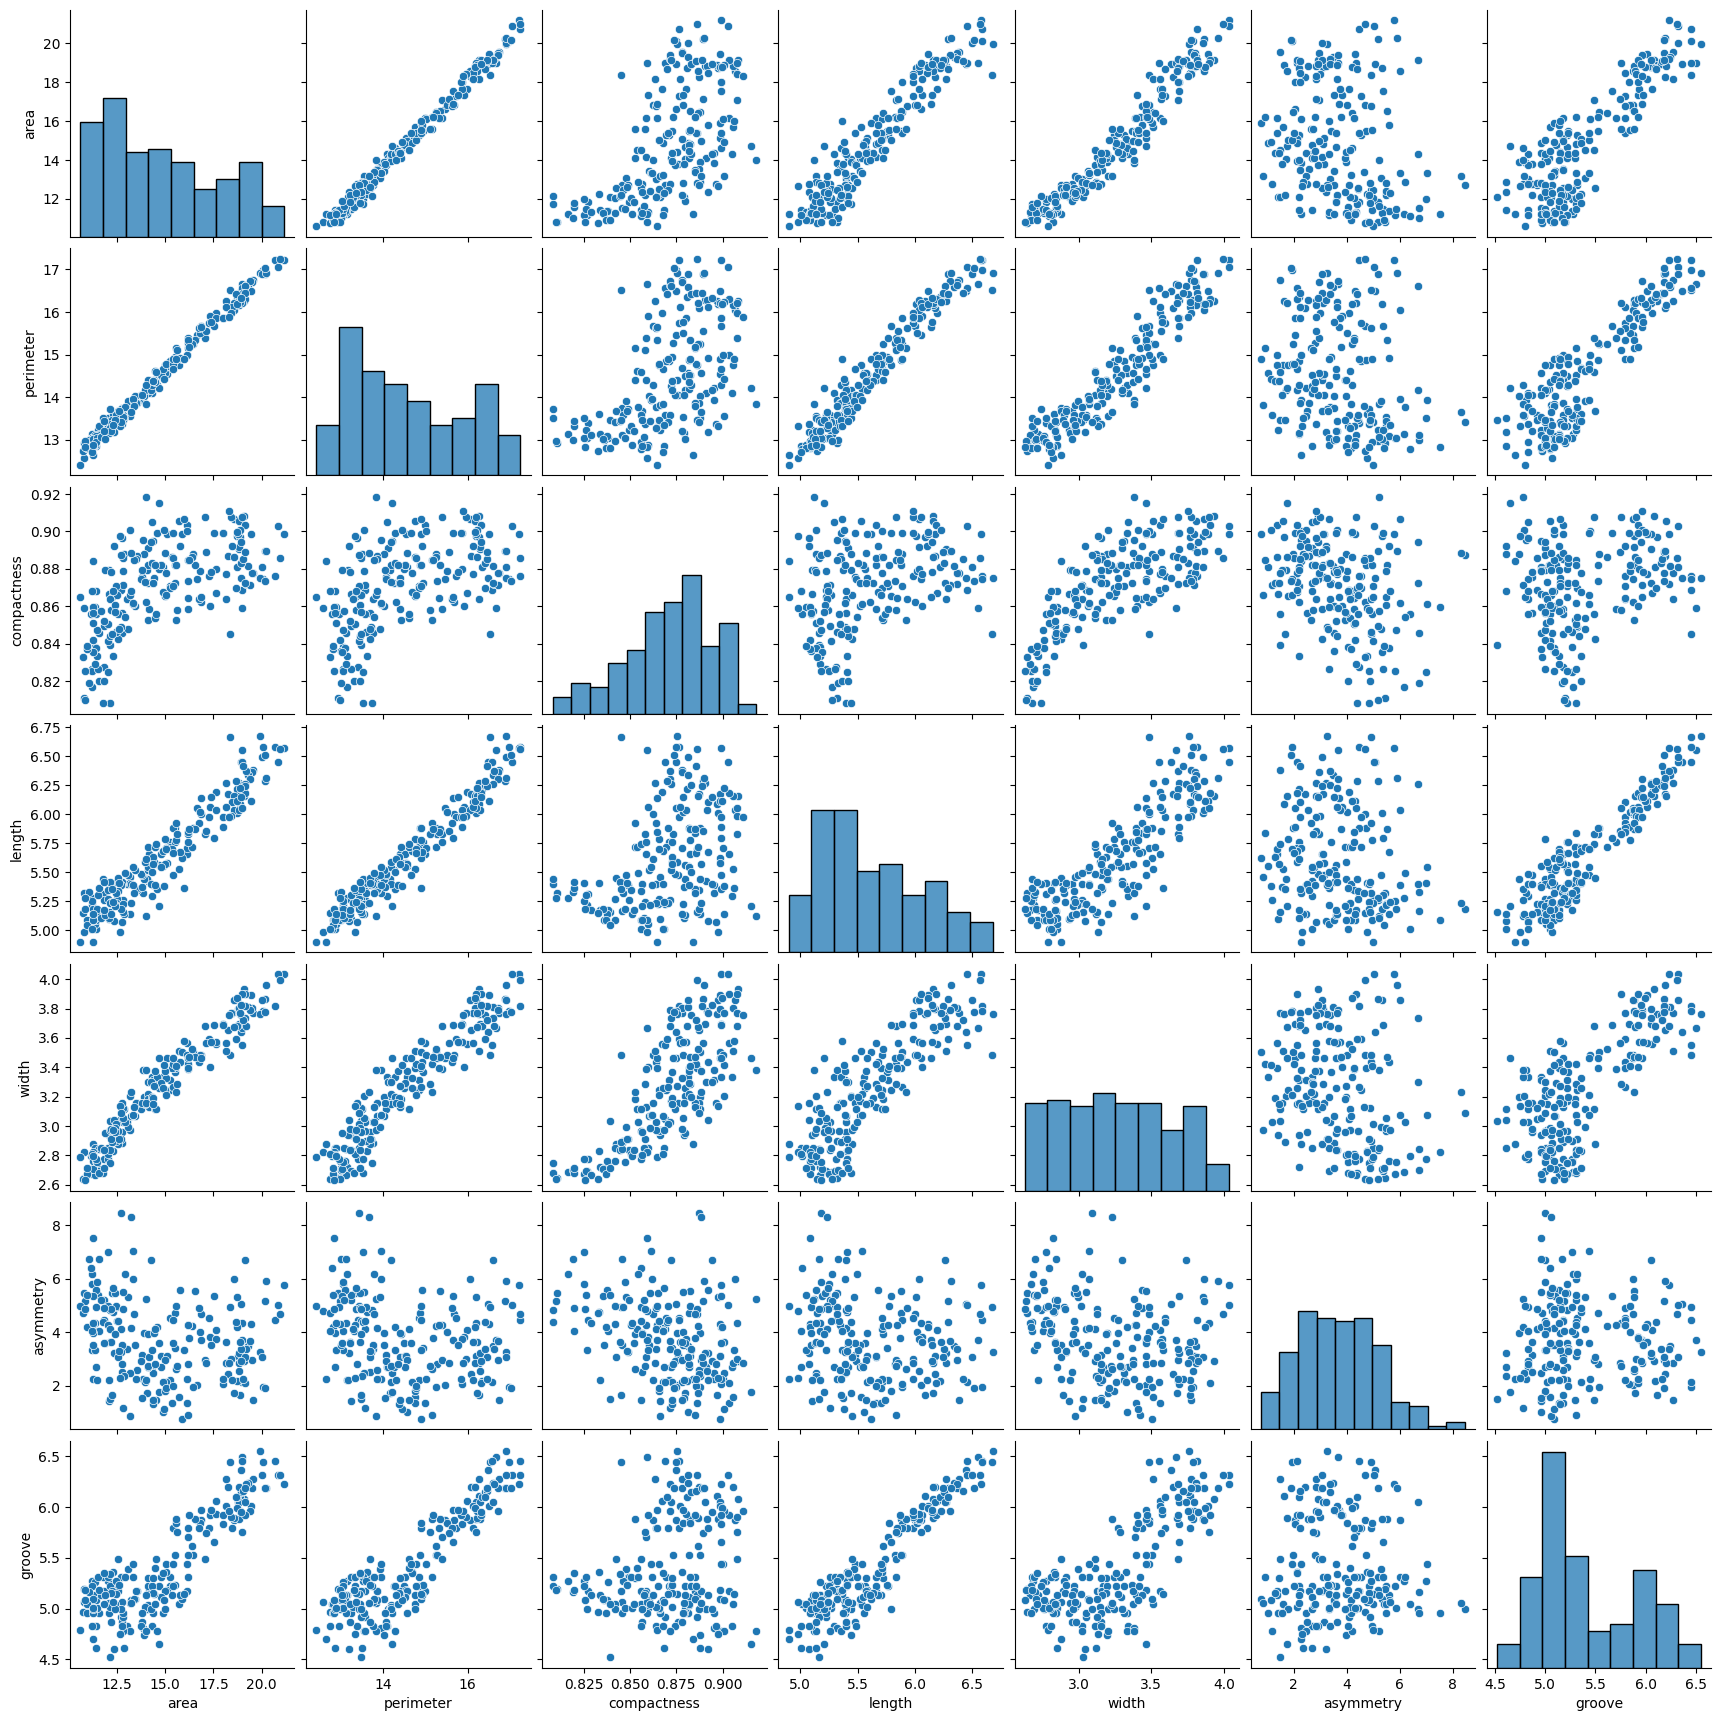

In [100]:
sns.pairplot(X_seeds)
plt.show()

1. Scale features appropriately for Euclidean geometry. 

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_seeds_std = scaler.fit_transform(X_seeds_array)

2. Compute hierarchical clustering with **complete** and **Ward** linkages; plot both dendrograms. Use short leaf labels such as the row index or `variety` numbers.


In [102]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

# For Complete linkage: compute distance matrix first
distance_matrix = pdist(X_seeds_std, metric="euclidean")
complete_seeds = linkage(distance_matrix, method="complete")

# For Ward linkage: pass the SCALED observation matrix directly (not distances)
ward_seeds = linkage(X_seeds_std, method="ward")

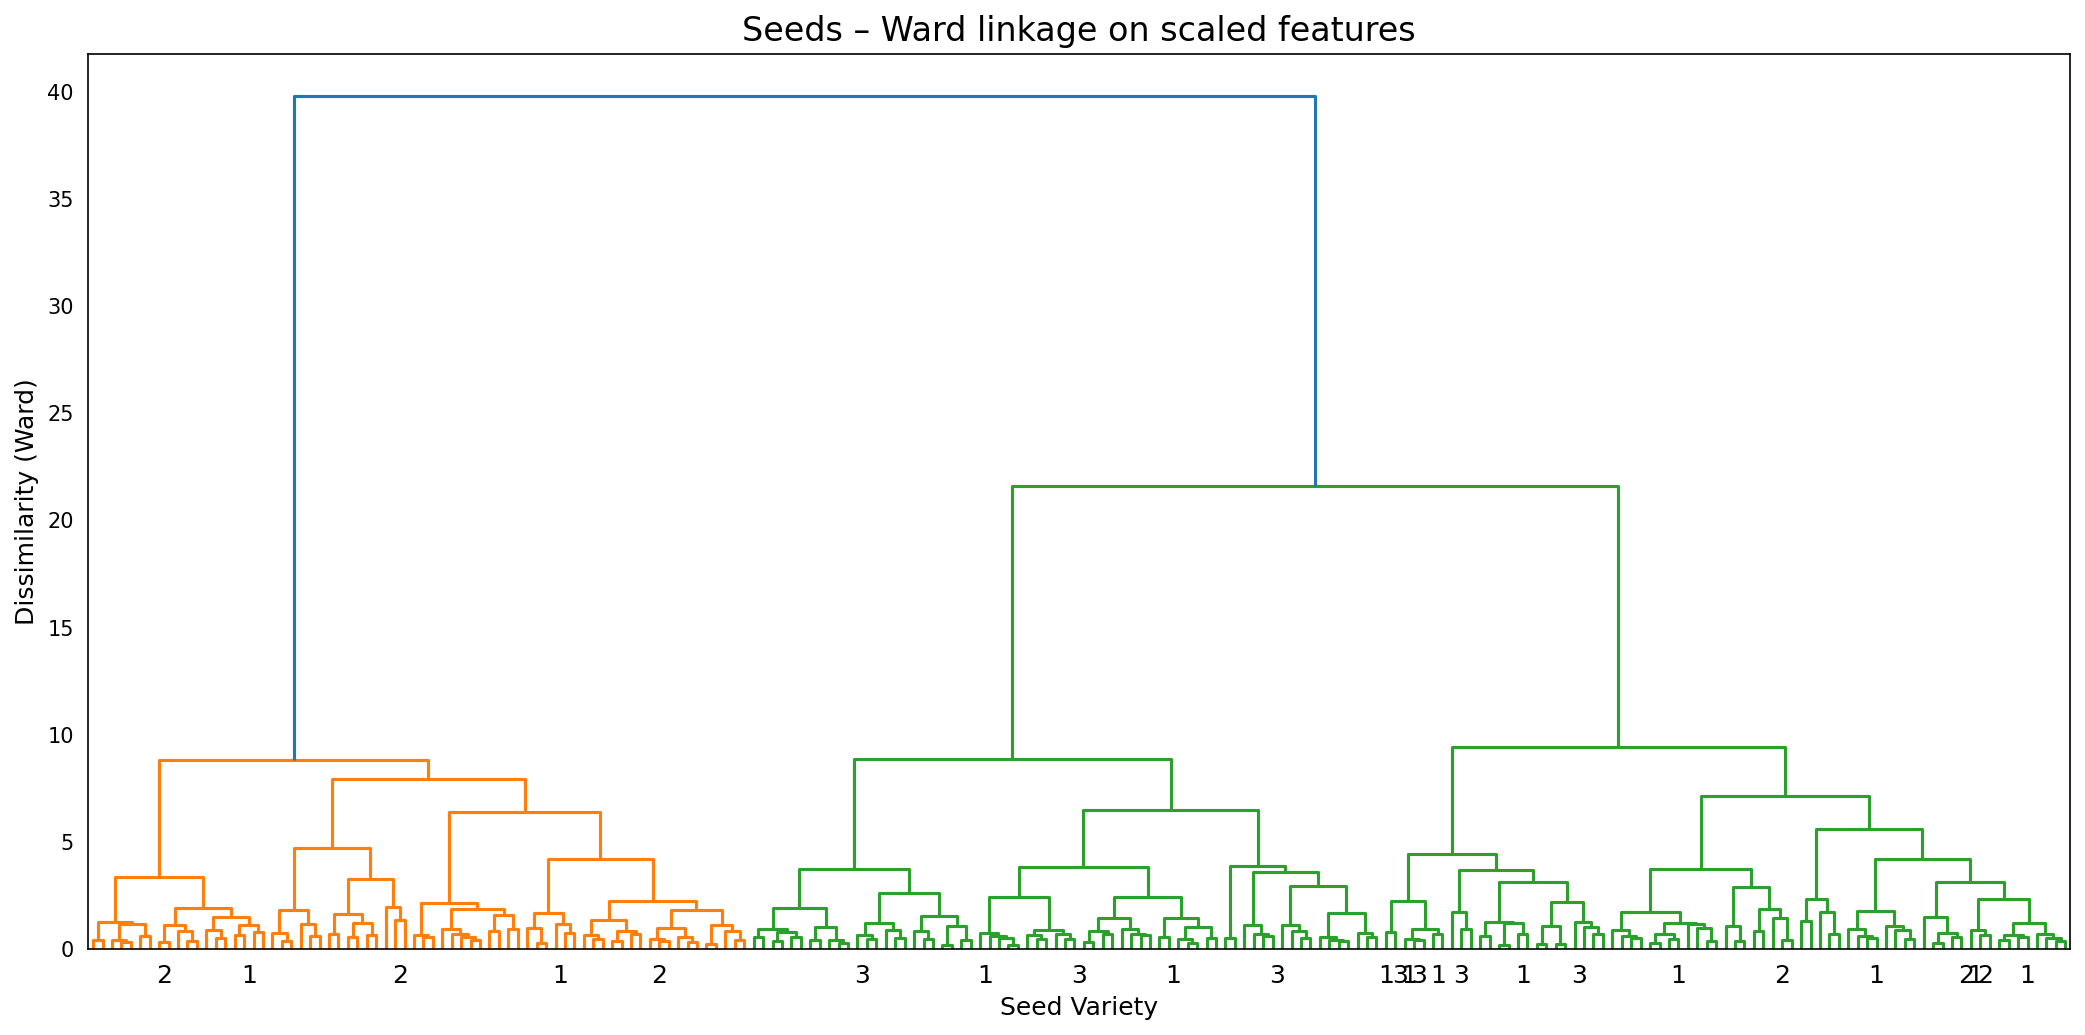

In [103]:
from itertools import groupby

from scipy.cluster.hierarchy import dendrogram

# Get the dendrogram data without plotting to extract leaf order
R = dendrogram(ward_seeds, no_plot=True)
ordered_labels_indices = [int(i) for i in R["ivl"]]
ordered_labels = y_true.astype(str)[ordered_labels_indices]

# Group consecutive identical labels
grouped_labels = []
for k, g in groupby(ordered_labels):
	grouped_labels.append(list(g))

# Calculate the position and label for each group
tick_positions = []
tick_labels = []
current_pos = 0
for group in grouped_labels:
	group_size = len(group)
	# The tick position is the midpoint of the group's span on the x-axis.
	# The dendrogram places leaves at positions 5, 15, 25, ...
	# so we multiply the index by 10 and add 5.
	tick_pos = (current_pos + group_size / 2.0) * 10 - 5
	tick_positions.append(tick_pos)
	tick_labels.append(group[0])  # The label for the group
	current_pos += group_size

# Plotting the Dendrogram
plt.figure(figsize=(14, 7), dpi=150)
ax = plt.gca()

# Plot the dendrogram, but prevent it from drawing its own labels
dendrogram(
	ward_seeds,
	ax=ax,
	leaf_label_func=lambda x: "",  # Hides the original leaf labels
	leaf_rotation=0,  # Ensures the (hidden) leaves are vertical
)

# Apply our custom, grouped labels to the x-axis
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=12)

# Aesthetic Improvements
ax.grid(False)  # Remove the background grid for a cleaner look
ax.tick_params(axis="x", which="both", bottom=False)  # Remove x-axis tick lines
ax.tick_params(
	axis="y", which="both", left=False, right=False
)  # Remove y-axis tick lines

plt.title("Seeds – Ward linkage on scaled features", fontsize=16)
plt.ylabel("Dissimilarity (Ward)", fontsize=12)
plt.xlabel("Seed Variety", fontsize=12)
plt.tight_layout()
plt.show()

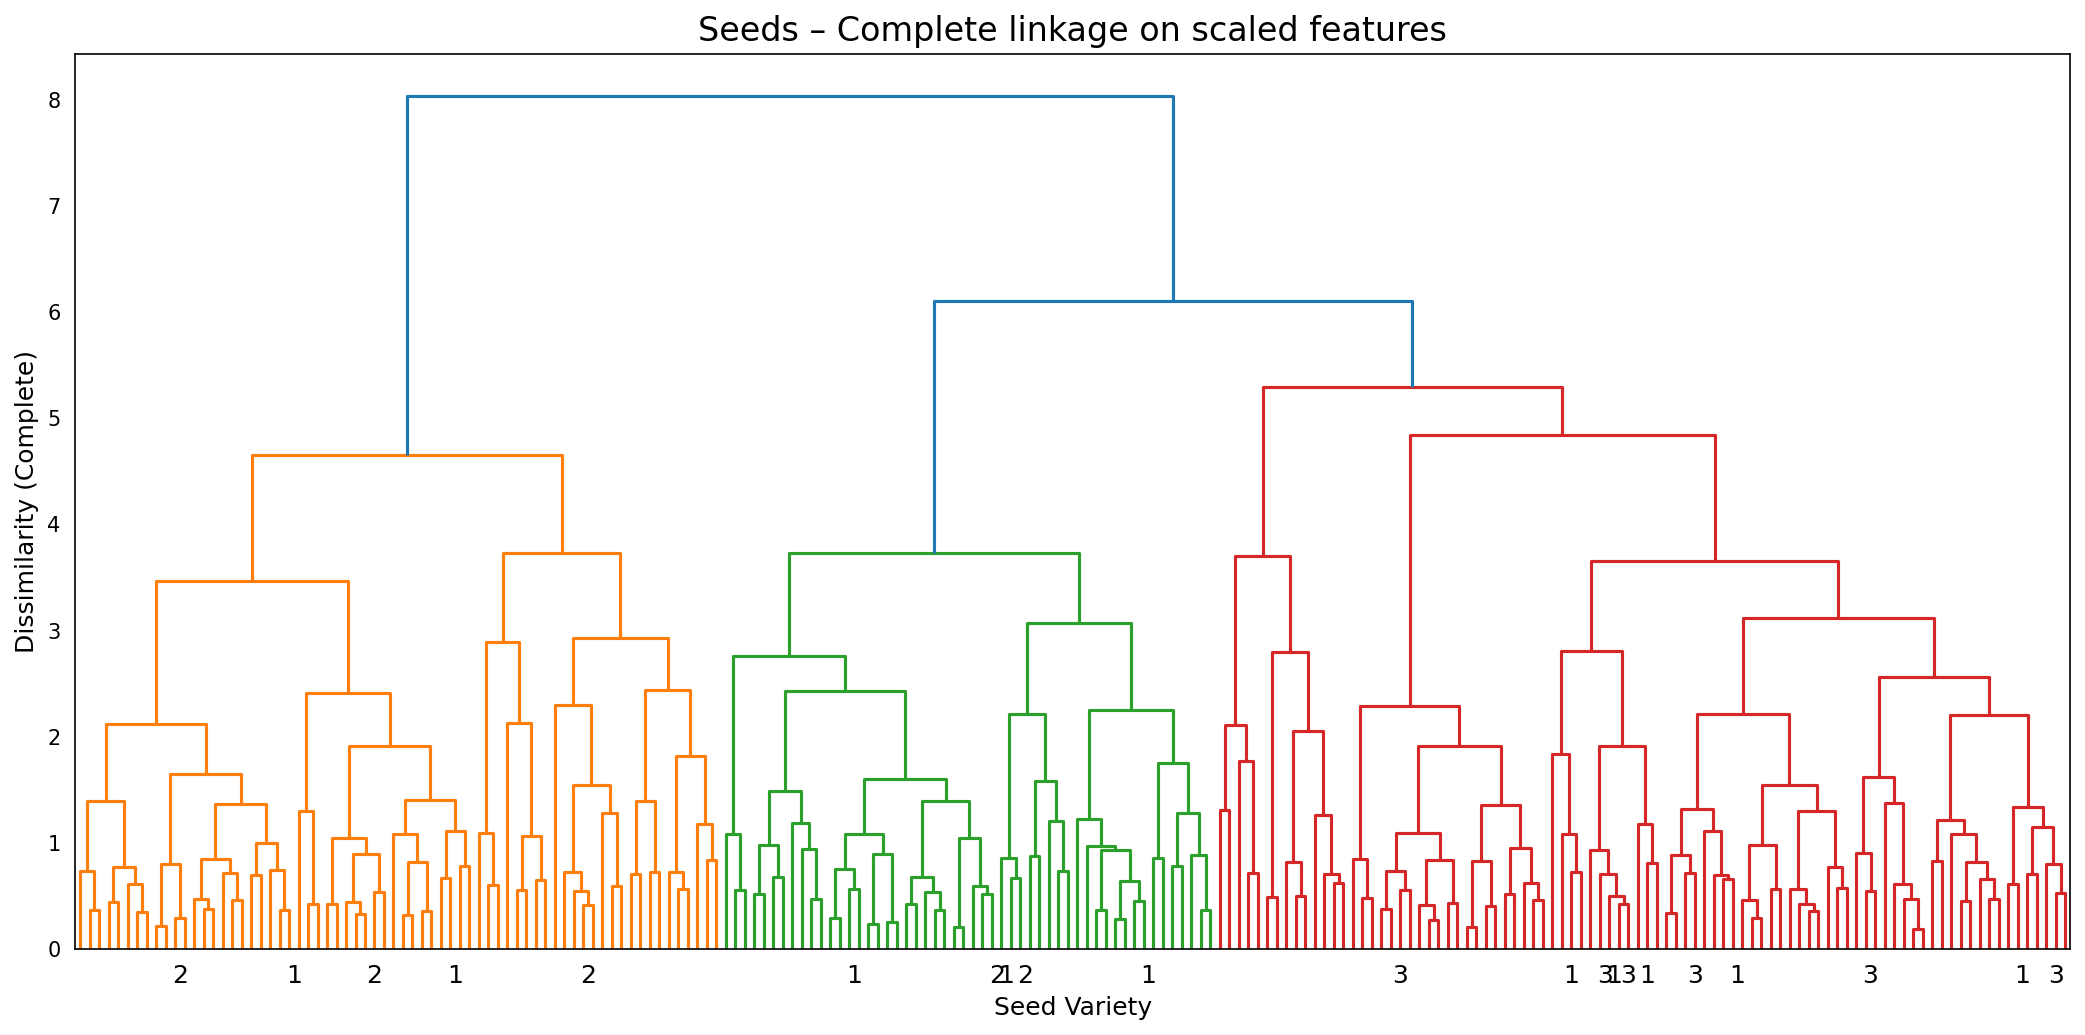

In [104]:
from itertools import groupby

R = dendrogram(complete_seeds, no_plot=True)
ordered_labels_indices = [int(i) for i in R["ivl"]]
ordered_labels = seeds["variety"].astype(str).iloc[ordered_labels_indices].values

# Group consecutive identical labels
grouped_labels = []
for k, g in groupby(ordered_labels):
	grouped_labels.append(list(g))

# Calculate the position and the label for each group
tick_positions = []
tick_labels = []
current_pos = 0
for group in grouped_labels:
	group_size = len(group)
	# The tick position is the midpoint of the group's span on the x-axis.
	# The dendrogram places leaves at positions 5, 15, 25, ...
	# so we multiply the index by 10 and add 5.
	tick_pos = (current_pos + group_size / 2.0) * 10 - 5
	tick_positions.append(tick_pos)
	tick_labels.append(group[0])  # The label for the group
	current_pos += group_size


# 4. Plotting the Dendrogram
plt.figure(figsize=(14, 7), dpi=150)
ax = plt.gca()

# Plot the dendrogram, but prevent it from drawing its own labels
dendrogram(
	complete_seeds,
	ax=ax,
	leaf_label_func=lambda x: "",  # Hides the original leaf labels
	leaf_rotation=0,  # Ensures the (hidden) leaves are vertical
)

# Apply our custom, grouped labels to the x-axis
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=12)


# 5. Aesthetic Improvements
ax.grid(False)  # Remove the background grid for a cleaner look
ax.tick_params(axis="x", which="both", bottom=False)  # Remove x-axis tick lines
ax.tick_params(
	axis="y", which="both", left=False, right=False
)  # Remove y-axis tick lines

plt.title("Seeds – Complete linkage on scaled features", fontsize=16)
plt.ylabel("Dissimilarity (Complete)", fontsize=12)
plt.xlabel("Seed Variety", fontsize=12)
plt.tight_layout()
plt.show()

3. Cut each tree into **three** clusters and compute **ARI** and **NMI** versus `y_true`. Which linkage aligns better with varieties, and why?

In [105]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

max_clusters = 3
clusters_complete = fcluster(Z=complete_seeds, t=max_clusters, criterion="maxclust")
ami_complete = adjusted_mutual_info_score(
	labels_true=y_true, labels_pred=clusters_complete
)
ari_complete = adjusted_rand_score(labels_true=y_true, labels_pred=clusters_complete)

print(f"Complete method - ARI: {ari_complete:.4f}, AMI: {ami_complete:.4f}")

Complete method - ARI: 0.6863, AMI: 0.6983


In [106]:
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

# Compute Ward linkage on the scaled observation matrix (not a distance matrix)
ward_seeds = linkage(X_seeds_std, method="ward")

max_clusters = 3
clusters_ward = fcluster(Z=ward_seeds, t=max_clusters, criterion="maxclust")
ami_ward = adjusted_mutual_info_score(labels_true=y_true, labels_pred=clusters_ward)
ari_ward = adjusted_rand_score(labels_true=y_true, labels_pred=clusters_ward)

print(f"Ward method - ARI: {ari_ward:.4f}, AMI: {ami_ward:.4f}")

Ward method - ARI: 0.7970, AMI: 0.7476


4. Report the **cophenetic correlation** for each tree; comment on the difference to the external indices.

In [107]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

# Compute the distance matrix from the scaled features
distance_matrix = pdist(X_seeds_std, metric="euclidean")

# Compute cophenetic correlation for Ward linkage
coph_corr_ward, _ = cophenet(ward_seeds, distance_matrix)
print(f"Cophenetic correlation coefficient for Ward: {coph_corr_ward:.3f}")

# Compute cophenetic correlation for Complete linkage
coph_corr_complete, _ = cophenet(complete_seeds, distance_matrix)
print(f"Cophenetic correlation coefficient for Complete: {coph_corr_complete:.3f}")

Cophenetic correlation coefficient for Ward: 0.729
Cophenetic correlation coefficient for Complete: 0.713


5. Produce one clustermap of the **feature correlation matrix** clustered by average linkage. Identify any near-redundant block of features you might drop before modelling.

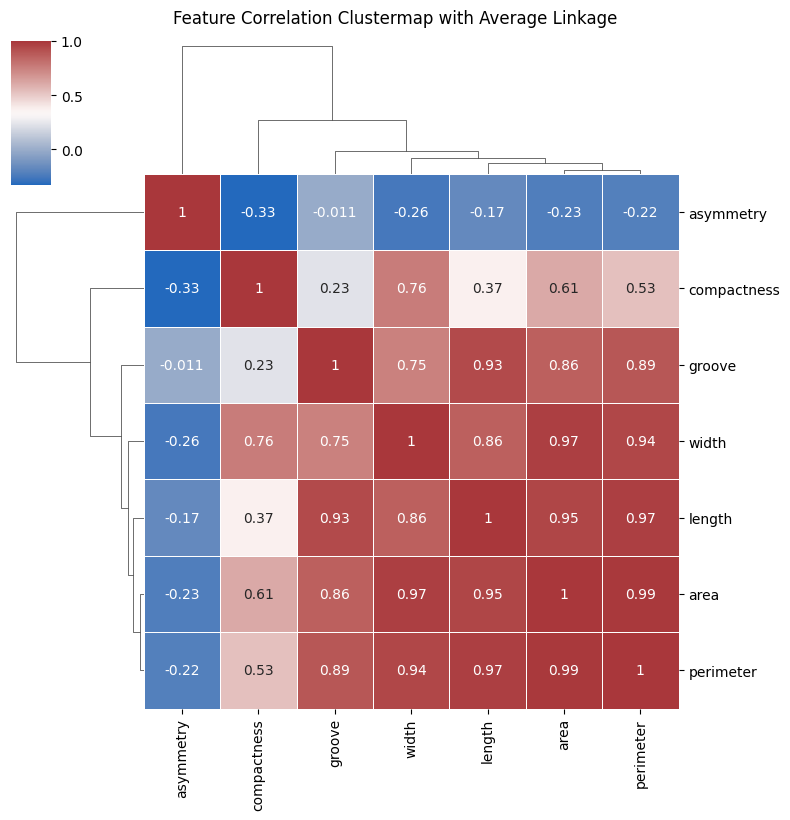

In [ ]:
corr_matrix = X_seeds.corr()

sns.clustermap(
	data=corr_matrix,
	method="average",
	metric="euclidean",
	cmap="vlag",
	linewidths=0.5,
	figsize=(8, 8),
	annot=True,
)

plt.suptitle("Feature Correlation Clustermap with Average Linkage", y=1.02)
plt.show()

In [109]:
from sklearn.decomposition import PCA

features = ["perimeter", "area", "length", "width"]
X_seeds_red = X_seeds[features]

scaler.fit_transform(X_seeds_red)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_seeds_red)

print(f"Number of principal components found: {pca.n_components_}")

Number of principal components found: 2


In [110]:
X_to_pca = X_seeds.drop(columns=features)
X_to_pca_scaled = scaler.fit_transform(X_to_pca)
X_reduced = np.concatenate([X_pca, X_to_pca_scaled], axis=1)

In [ ]:
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

# For Ward linkage we must pass the observation matrix (n_samples, n_features), not a condensed distance matrix.
ward_seeds_reduced = linkage(X_reduced, method="ward")

max_clusters = 3
clusters_pca = fcluster(ward_seeds_reduced, t=max_clusters, criterion="maxclust")

# Evaluate the flat cluster labels against the true labels
ami_max = adjusted_mutual_info_score(y_true, clusters_pca)
ari_max = adjusted_rand_score(y_true, clusters_pca)

print(f"Ward method - ARI: {ari_max:.4f}, AMI: {ami_max:.4f}")

Ward method - ARI: 0.6693, AMI: 0.6931


In [112]:
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

X_seeds_dropped = X_seeds.drop(columns=["perimeter", "area"])
scaler.fit_transform(X_seeds_dropped)

ward_seeds_dropped = linkage(X_seeds_dropped, method="ward")
clusters_dropped = fcluster(ward_seeds_dropped, t=max_clusters, criterion="maxclust")

# Evaluate the flat cluster labels against the true labels
ami_max = adjusted_mutual_info_score(y_true, clusters_dropped)
ari_max = adjusted_rand_score(y_true, clusters_dropped)

print(f"Ward method - ARI: {ari_max:.4f}, AMI: {ami_max:.4f}")

Ward method - ARI: 0.1891, AMI: 0.2480


Neither dropping features nor reducing features with PCA improved overall ARI or AMI scores at all. I see no point in dropping features even though they're highly correlated.

### Exercise 2 — **Stock co-movement**: correlation distance + average linkage

**Tasks.**

1. Explain in ≤5 sentences why **correlation distance** (or cosine) is appropriate here and why Ward is inappropriate.
2. Build a dendrogram using **average linkage** on **correlation distance** between rows of `M`.
3. Cut the tree at (k\in{3,4,5}). For each cut: compute within-cluster **mean pairwise correlation** and produce a **heatmap** per cluster.
4. Assign informal cluster names (e.g., “large-cap tech”, “defensives”, “energy”). Provide a compact mapping table `ticker → cluster → label`.
5. Sanity check: redo with **StandardScaler + Ward (Euclidean)** and show how it answers a *different* question (overall return magnitude structure rather than shape). Defend your preferred specification.

**Acceptance.**
– One dendrogram, one diagnostic figure (either elbow of within-cluster correlations or a silhouette computed on correlation distances), one mapping table, and an 8–10 sentence executive summary.



In [113]:
import yfinance as yf

tickers = [
	"AAPL",
	"MSFT",
	"GOOGL",
	"AMZN",
	"META",
	"NVDA",
	"TSLA",
	"JPM",
	"V",
	"PG",
	"XOM",
	"CVX",
	"KO",
	"PEP",
	"HD",
	"NKE",
	"INTC",
	"ADBE",
	"NFLX",
	"CSCO",
]

# Download with explicit auto_adjust parameter and increased timeout
data = yf.download(
	tickers, start="2018-01-01", end="2024-12-31", auto_adjust=True, timeout=30
)

# Handle the MultiIndex structure returned by yfinance
if isinstance(data.columns, pd.MultiIndex):
	prices = data["Close"].dropna()
else:
	prices = data.dropna()

rets = np.log(prices).diff().dropna()  # daily log returns
M = rets.to_numpy().T  # rows=stocks, cols=days
names = rets.columns.to_list()

[*********************100%***********************]  20 of 20 completed



1. Explain in ≤5 sentences why **correlation distance** (or cosine) is appropriate here and why Ward is inappropriate.

>Correlation distance (or cosine distance) is appropriate for clustering stock returns because it captures the similarity in directional co-movements of time series data, ignoring differences in magnitude or volatility, which is crucial for financial assets where patterns of ups and downs matter more than absolute scale. These distances normalize the data, making them appropriate to varying stock prices or return volatilities across the portfolio. In contrast, Ward linkage is inappropriate because it is specifically designed for Euclidean distances and minimizes intra-cluster variance in an L2 sense, leading to distorted or invalid cluster formations when applied to non-Euclidean metrics like correlation, which violate the geometric assumptions of Ward's method. 

2. Build a dendrogram using **average linkage** on **correlation distance** between rows of `M`.

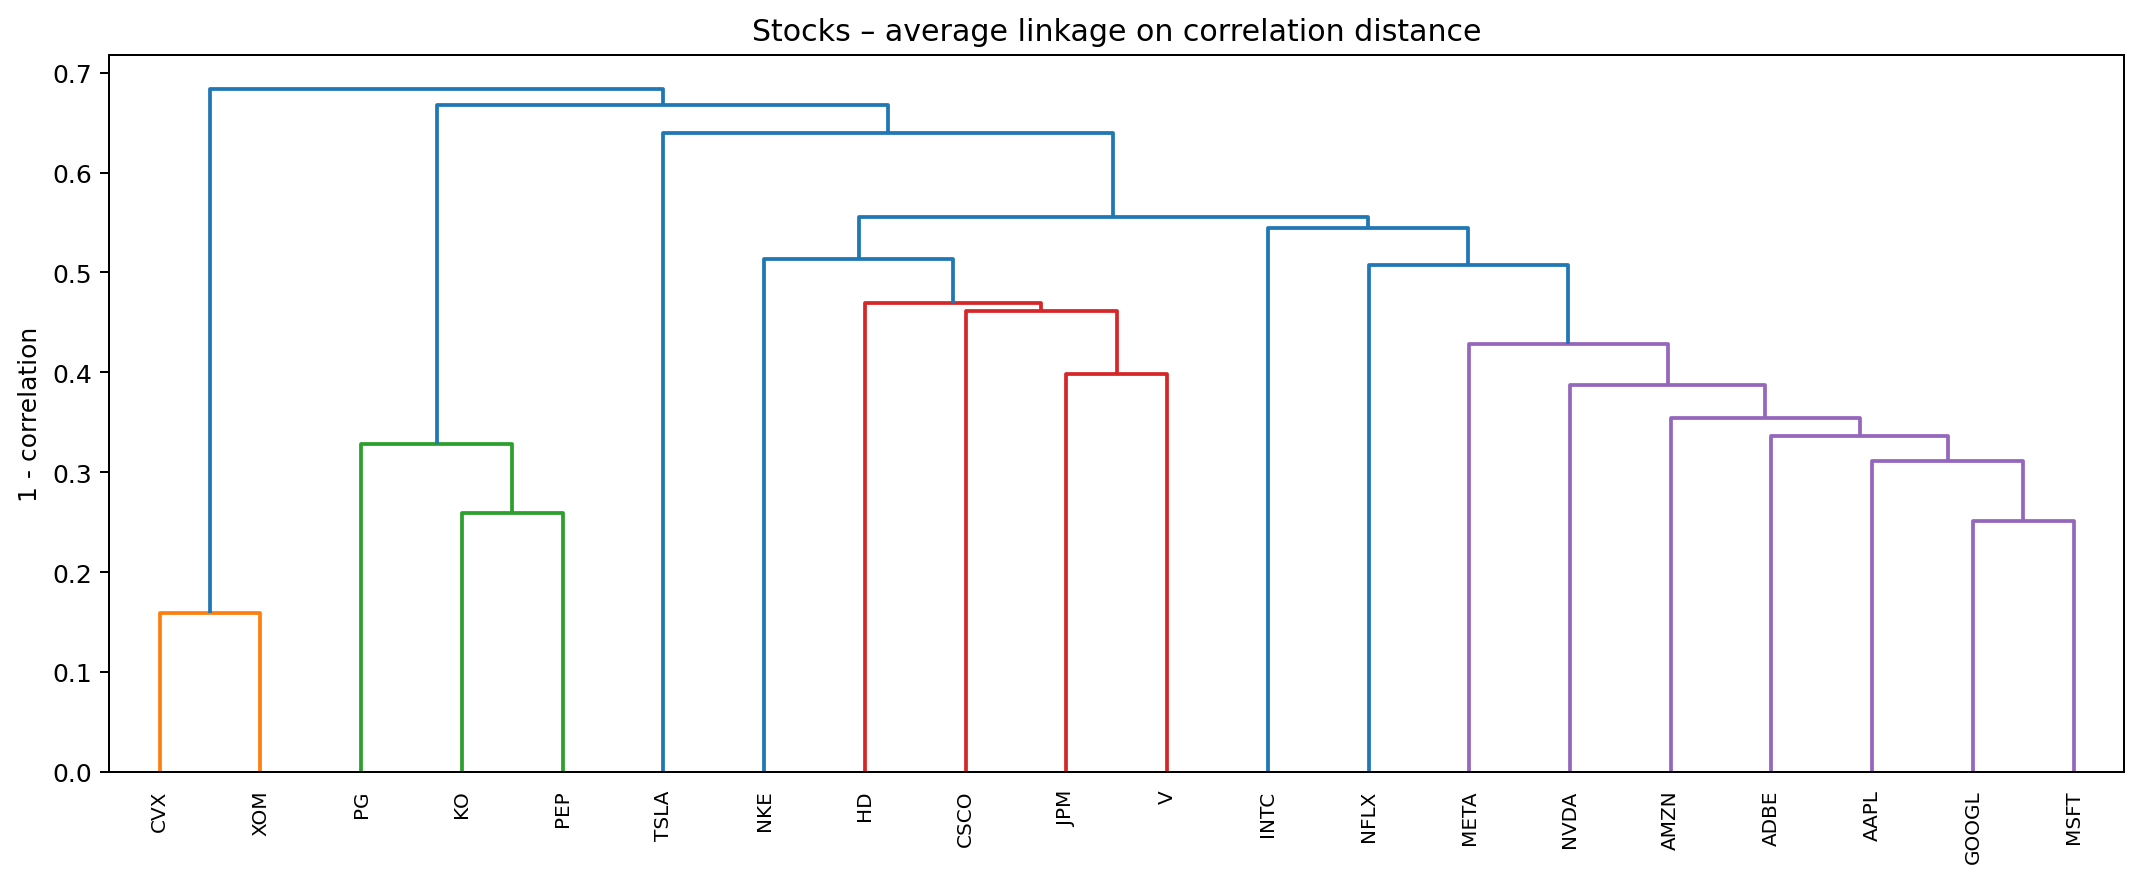

In [114]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

D = pdist(M, metric="correlation")
Z = linkage(D, method="average")

plt.figure(figsize=(12, 5), dpi=180)
dendrogram(Z, labels=names, leaf_rotation=90, leaf_font_size=8)
plt.title("Stocks – average linkage on correlation distance")
plt.ylabel("1 - correlation")
plt.grid(False)
plt.tight_layout()
plt.show()

## Session A — K-means, properly

### 1) The idea, stated precisely

* **Objective.** Partition data ($X=\{x_i\}_{i=1}^n\subset\mathbb{R}^d$) into ($k$) clusters and pick centroids ($\{\mu_j\}_{j=1}^k$) to minimize within-cluster **SSE** (sum of squared errors):
	$$
	\min_{\{\mu_j\},\{c(i)\}} \sum_{i=1}^n \left\|x_i - \mu_{c(i)}\right\|_2^2.
	$$
	With Euclidean distance and squared loss, the minimizer of each cluster's SSE is the **mean** (hence "k-means").
* **Lloyd's algorithm (what `KMeans.fit` does).** Iterate until assignments stop changing:

	1. **Assign:** $c(i) \leftarrow \arg\min_j \|x_i-\mu_j\|^2$.
	2. **Update:** $\mu_j \leftarrow \frac{1}{|C_j|}\sum_{i:c(i)=j} x_i$.
		 Converges to a **local** minimum; not guaranteed global optimality.
* **Initialization.** Random centroids are fragile. **k-means++** initializes by spreading seeds roughly proportional to squared distance; this reduces bad local minima and speeds convergence.
* **Assumptions baked in.** Clusters are roughly **spherical**, of **similar variance** and **comparable size** in a **Euclidean** space. If your data violate these, k-means can "make" clusters even where there aren't good ones.
* **Why scaling matters.** The objective uses Euclidean norm. A feature with larger scale dominates distances, so **StandardScaler** is typically essential when units differ.
* **Outliers.** Squared loss gives them huge leverage; a single extreme point can drag a centroid. Robust variants (k-medoids, trimmed k-means) handle this better.
* **Complexity.** Per iteration ($O(nkd)$). Memory ($O(nd)$). Practical behavior is excellent for medium-sized tabular data.

## 2) Diagnostics and what they really mean

* **Inertia (WCSS).** The minimized objective value. It **always decreases** with larger ($k$). Use it as a *monotone trend*, not a target.
* **Silhouette.** For each point ($i$):
	$a_i=$ mean intra-cluster distance, $b_i=$ smallest mean distance to another cluster,
	$s_i=(b_i-a_i)/\max(a_i,b_i)\in[-1,1]$.
	Mean silhouette gives separation vs. compactness; distributions of ($s_i$) reveal *which* clusters are messy.
* **Calinski–Harabasz (CH)** and **Davies–Bouldin (DB)** indices give additional, differently scaled signals.
* **Stability.** If clusterings jump around across seeds or resampled data, the structure is weak. Use ARI/NMI between runs to quantify.
* **Explainers.** Inspect **centroids** (and **nearest exemplars** to the centroids). For images, *reshape centroid vectors into images* to see what each cluster "represents".

## 3) When k-means is a poor fit

* Strongly **elongated**/manifold clusters → try spectral clustering, GMMs, or density-based methods.
* **Different scales/units** and you refuse to scale → distances are meaningless.
* **Categorical features** → need proper encodings and a suitable distance (k-modes, k-prototypes, or dissimilarities).


### Dataset for Session A

We’ll use **Digits** (handwritten digits, real and noisy; 1,797 samples × 64 features). It’s built into scikit-learn, so no links or downloading required.


In [115]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data.astype(float)
y_true = digits.target

feature_names = [f"px{j}" for j in range(X.shape[1])]

### 4) Exercises (your code)

#### Part A — Baseline, scaling, and (k)-scan

1. **Scale** `X` with `StandardScaler`. Keep both `X_std` and `X` to compare.

2. For (k = 2..12): fit k-means **with k-means++** (`n_init`≥20) on `X_std`. Record: inertia, mean silhouette, CH, DB.

3. **Plots.** Two panels: Elbow (inertia vs k) and Silhouette vs k.

   * **Acceptance:** Curves render cleanly; code separates data prep, fit, and plotting.

4. **Discuss** in a short cell (markdown): what k do the *indices* suggest? Where do they disagree? Mention at least one reason each index might mislead on Digits.

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [117]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
	calinski_harabasz_score,
	davies_bouldin_score,
	silhouette_score,
)

ks = np.arange(2, 13)
results = []

for k in ks:
	kmeans = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
	kmeans.fit(X_std)
	labels = kmeans.predict(X_std)
	results.append({
		"k": k,
		"inertia": kmeans.inertia_,
		"silhouette": silhouette_score(X_std, labels),
		"calinski_harabasz": calinski_harabasz_score(X_std, labels),
		"davies_bouldin": davies_bouldin_score(X_std, labels),
	})

df_metrics = pd.DataFrame(results)
display(df_metrics)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,100423.843034,0.105638,164.320706,2.964291
1,3,93836.385370,0.105438,150.849921,2.754794
2,4,89120.988733,0.095432,137.451154,2.514831
3,5,85096.054668,0.102298,129.093923,2.252927
4,6,81678.466699,0.098789,122.524125,2.261248
5,7,77671.338917,0.121995,122.702347,2.047125
6,8,74854.159172,0.126590,118.689315,2.016211
7,9,72025.614944,0.130743,116.648425,1.957181
8,10,69486.514474,0.142321,114.671615,1.886166
9,11,67261.847461,0.153194,112.465395,1.803047


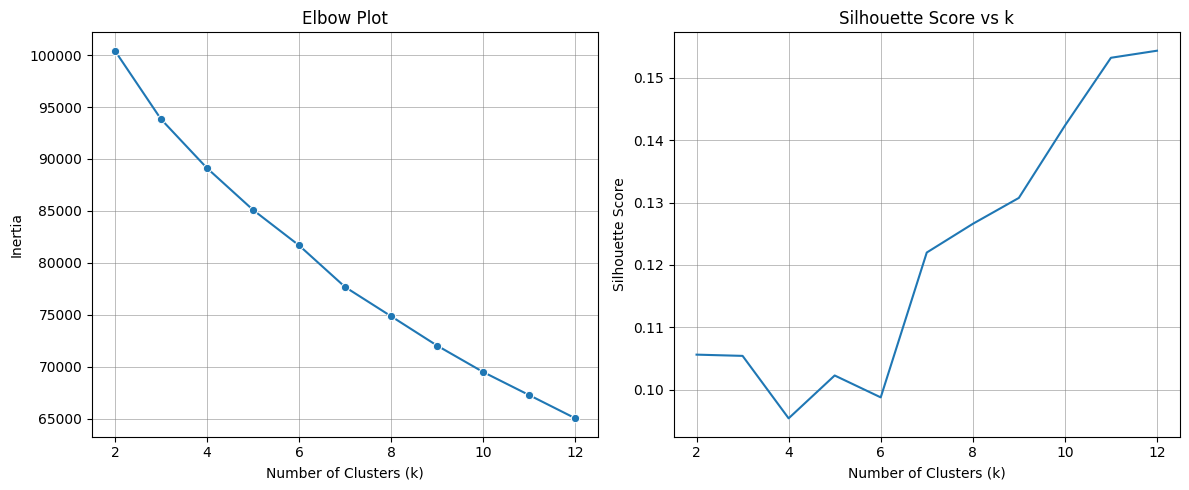

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data=df_metrics, x="k", y="inertia", ax=axes[0], marker="o")
axes[0].set(xlabel="Number of Clusters (k)", ylabel="Inertia", title="Elbow Plot")
axes[0].grid(True, alpha=0.6, linewidth=0.6, color="grey")

sns.lineplot(data=df_metrics, x="k", y="silhouette", ax=axes[1])
axes[1].set(
	xlabel="Number of Clusters (k)",
	ylabel="Silhouette Score",
	title="Silhouette Score vs k",
)
axes[1].grid(True, alpha=0.6, linewidth=0.6, color="grey")

plt.tight_layout()
plt.show()



### Part B — Inspect clusters, not just scores

5. Fit your **candidate k** on `X_std`.

6. **Per-cluster diagnostics:** cluster sizes; clusterwise mean silhouette; 10 **worst** points by silhouette (list their indices and true digits for audit only).

   * **Acceptance:** Table with `cluster_id`, `size`, `mean_silhouette`, and a small list of worst points per cluster.

7. **Centroid visualizations.** Reshape each centroid to $(8 \times 8)$ and show a grid of images. Also show the **nearest training image** to each centroid.

   * **Acceptance:** Side-by-side centroid vs nearest exemplar for at least 6 clusters; include a one-sentence observation per cluster.



In [119]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=11, init="k-means++", n_init="auto", random_state=42)
kmeans.fit(X_std)
labels = kmeans.predict(X_std)

In [120]:
from sklearn.metrics import silhouette_samples

# Get per-point silhouette scores
silhouette_vals = silhouette_samples(X_std, labels)

# Create a DataFrame for analysis
cluster_analysis = []

for cluster_id in np.unique(labels):
	cluster_mask = labels == cluster_id
	cluster_silhouettes = silhouette_vals[cluster_mask]
	cluster_indices = np.where(cluster_mask)[0]

	# Get 10 worst points by silhouette
	worst_indices = cluster_indices[np.argsort(cluster_silhouettes)[:10]]
	worst_true_digits = y_true[worst_indices]

	cluster_analysis.append({
		"cluster_id": cluster_id,
		"size": np.sum(cluster_mask),
		"mean_silhouette": np.mean(cluster_silhouettes),
		"worst_indices": worst_indices.tolist(),
		"worst_true_digits": worst_true_digits.tolist(),
	})

# Convert to DataFrame for display
df_cluster_analysis = pd.DataFrame(cluster_analysis)

# Display the analysis
display(df_cluster_analysis[["cluster_id", "size", "mean_silhouette"]])

# Show worst points for each cluster
for _, row in df_cluster_analysis.iterrows():
	print(f"\nCluster {row['cluster_id']} - 10 worst points:")
	print(f"Indices: {row['worst_indices']}")
	print(f"True digits: {row['worst_true_digits']}")

,cluster_id,size,mean_silhouette
0,0,29,0.051657
1,1,138,0.102386
2,2,104,0.176777
3,3,179,0.170023
4,4,179,0.221884
5,5,180,0.344061
6,6,170,0.055620
7,7,410,0.103875
8,8,2,0.118536
9,9,246,0.144227



Cluster 0 - 10 worst points:
Indices: [765, 438, 655, 393, 1467, 1009, 1012, 498, 263, 1033]
True digits: [9, 7, 9, 7, 7, 7, 4, 7, 7, 4]

Cluster 1 - 10 worst points:
Indices: [1448, 418, 1240, 1571, 1660, 847, 910, 625, 1635, 1713]
True digits: [5, 5, 3, 8, 4, 5, 5, 5, 7, 5]

Cluster 2 - 10 worst points:
Indices: [795, 1551, 645, 643, 27, 341, 1542, 51, 1204, 480]
True digits: [9, 6, 8, 8, 7, 1, 8, 2, 1, 7]

Cluster 3 - 10 worst points:
Indices: [1666, 1595, 1728, 1750, 633, 1605, 1570, 1037, 226, 530]
True digits: [8, 7, 7, 3, 5, 3, 7, 8, 3, 4]

Cluster 4 - 10 worst points:
Indices: [843, 574, 420, 604, 402, 1203, 782, 106, 1404, 569]
True digits: [6, 6, 6, 6, 6, 5, 6, 6, 5, 8]

Cluster 5 - 10 worst points:
Indices: [1591, 414, 1593, 1078, 1077, 792, 1615, 1287, 1598, 1768]
True digits: [0, 8, 2, 0, 0, 6, 0, 0, 0, 0]

Cluster 6 - 10 worst points:
Indices: [214, 826, 340, 187, 1557, 181, 1208, 668, 1751, 180]
True digits: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Cluster 7 - 10 worst points:
I

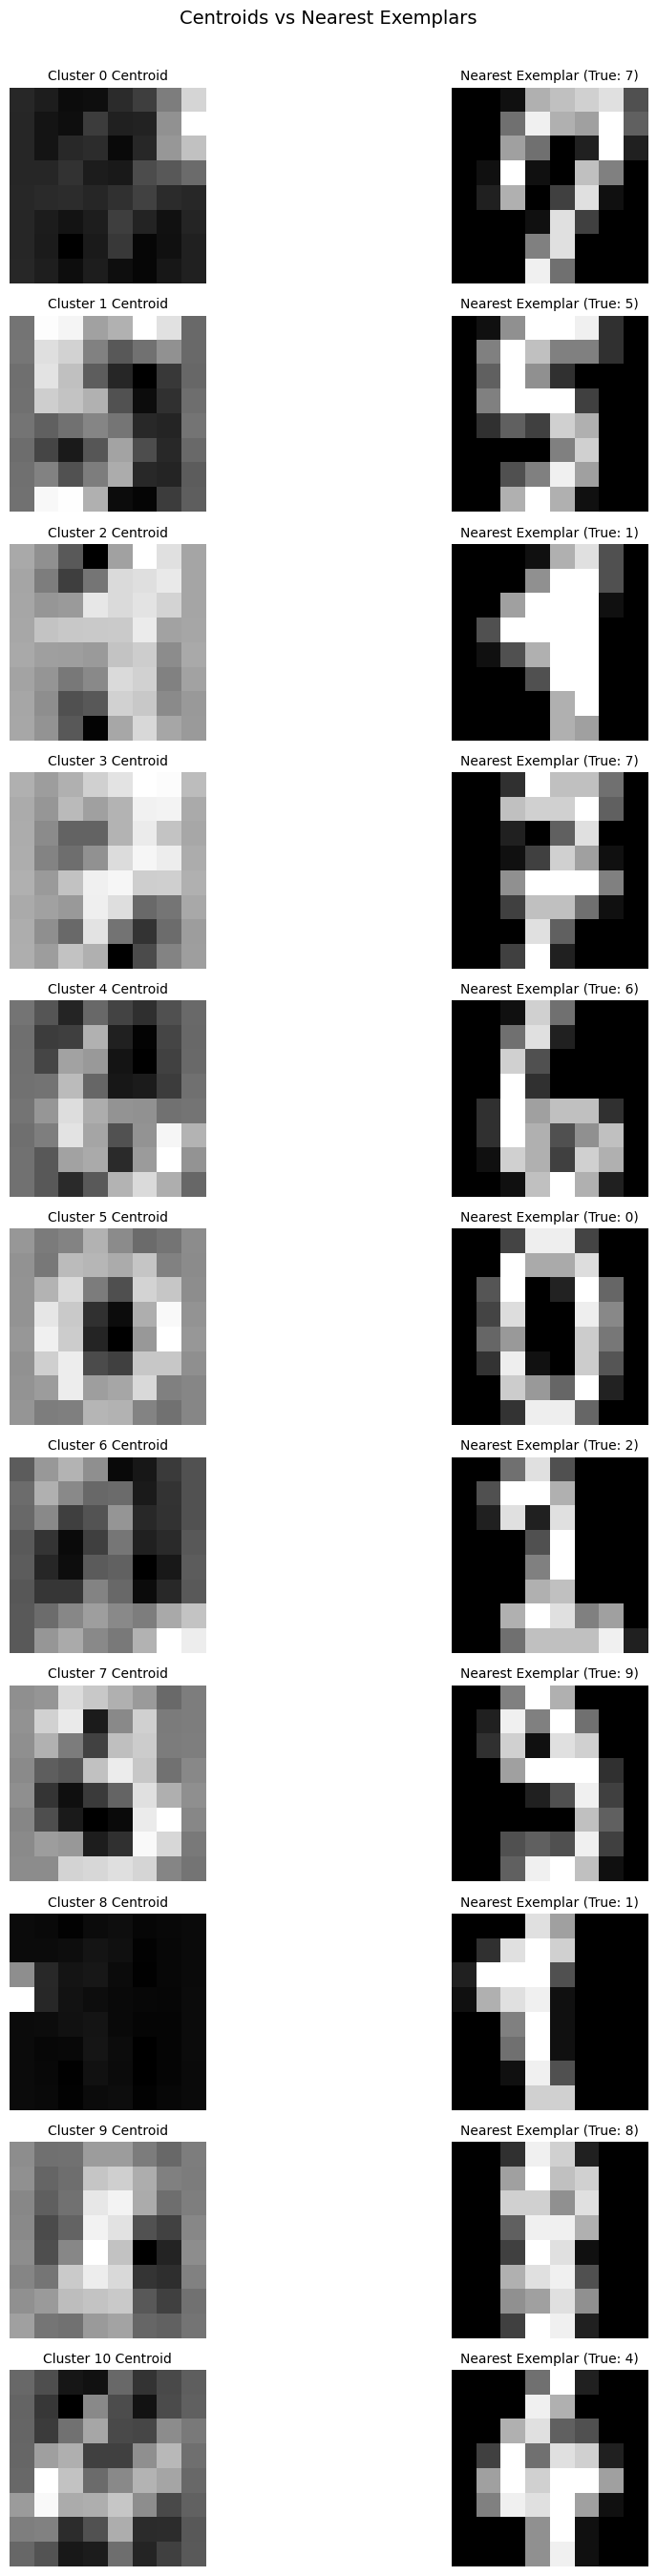

In [129]:
# Find nearest exemplar to each centroid
nearest_exemplars = []
for i in range(kmeans.n_clusters):
	cluster_mask = labels == i
	cluster_points = X_std[cluster_mask]
	centroid = kmeans.cluster_centers_[i]

	# Find nearest point to centroid
	distances = np.linalg.norm(cluster_points - centroid, axis=1)
	nearest_idx = np.where(cluster_mask)[0][np.argmin(distances)]
	nearest_exemplars.append(nearest_idx)

# Create visualization with better spacing
fig, axes = plt.subplots(kmeans.n_clusters, 2, figsize=(12, 2.5 * kmeans.n_clusters))
fig.suptitle(
	"Centroids vs Nearest Exemplars", fontsize=14, y=0.98
)  # Adjust y position and font size

for i in range(kmeans.n_clusters):
	# Centroid
	centroid_img = kmeans.cluster_centers_[i].reshape(8, 8)
	axes[i, 0].imshow(centroid_img, cmap="gray")
	axes[i, 0].set_title(f"Cluster {i} Centroid", fontsize=10)
	axes[i, 0].axis("off")

	# Nearest exemplar
	exemplar_img = X[nearest_exemplars[i]].reshape(8, 8)
	axes[i, 1].imshow(exemplar_img, cmap="gray")
	axes[i, 1].set_title(
		f"Nearest Exemplar (True: {y_true[nearest_exemplars[i]]})", fontsize=10
	)
	axes[i, 1].axis("off")

# Adjust layout to prevent title overlap
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Make room for the title
plt.show()

### Part C — Initialization, seeds, and stability

8. Compare **k-means++ vs random** init for your candidate (k): run each 30 times; log best inertia, median silhouette, and **ARI to y_true** (audit metric) across runs.

   * **Acceptance:** Summary table with rows `{kmeans++, random}`, columns `best_inertia`, `median_silhouette`, `median_ARI`, and a one-paragraph interpretation.

9. **Bootstrap stability.** Sample 80% of points **without replacement**; fit with the same (k); predict on the held-out 20%; compute ARI between successive bootstraps’ predictions on their overlap. Do this 30 bootstraps.

   * **Acceptance:** Distribution (boxplot) of ARIs; median ≥ 0.70 is “stable” for Digits; if lower, discuss why.



### Part D — Outliers and robustness

10. **Stress test:** add 30 artificial outliers by injecting high-variance Gaussian noise to random 64-D vectors and appending them to `X_std`. Refit with same (k).

* **Acceptance:** Report how cluster sizes and mean silhouettes change; note if any centroid gets “dragged”. Offer one mitigation (e.g., trimming or robust scaling).

### Part E — PCA as pre-processing (optional but recommended)

11. Fit PCA on `X_std` to retain **95%** variance; run the full (k=2..12) scan **again** on the PCA scores; compare the curves and your chosen (k).

* **Acceptance:** Overlaid curves (raw vs PCA) and a short note: did PCA sharpen separation or not?

### Part F — Final short report

12. In markdown (≤200 words), state:

* Your final (k), with **two** supporting diagnostics and **one** counter-signal you chose to discount.
* A **risk** you observed (e.g., one cluster mixing 3/5/8) and how you’d address it in production.
* One **business-style interpretation** enabled by centroid/exemplar inspection.

---

## 5) Hints you might want (but you must code)

* Use `silhouette_samples` to get per-point scores.
* “Nearest exemplar” = argmin distance from centroid to points in that cluster.
* For seeds/bootstraps, fix `random_state` only for reproducibility of *each* run; don’t reuse the same splits.
* When plotting centroid images, `plt.imshow(centroid.reshape(8,8), cmap="gray")`.
* For outliers, add then re-scale (or append to already scaled carefully—document your choice).
* If Digits feels too big for plotting, operate on a stratified subsample, but justify it.

---

If this structure works for you, run Part A and Part B at your pace. When you want, send me your outputs (plots/tables or notes). I’ll review like a lab instructor: I’ll point out what’s solid, what’s shaky, and where to dig deeper. After Session A, we’ll move to the same level of depth for **hierarchical clustering** (Session B: linkage choices, cophenetic correlation, `fcluster` by distance vs k, and careful dendrogram reading).
